In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from shapely.geometry import Point
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import datetime
from datetime import datetime
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from math import sin, cos, pi
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import roc_curve, auc


# Configuration avancée pour l'analyse
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)


 PROJET DATA SCIENCE : PRÉDICTION DES TYPES DE RETARDS DE VOLS


In [2]:
print("="*80)
print(" PROCESSING DES DONNEES ")
print("="*80)

 PROCESSING DES DONNEES 


In [3]:
# chargement des données
vols = pd.read_csv('/Users/konearounaromeo/Downloads/Airlines+Airports+Cancellation+Codes+&+Flights/flights.csv',low_memory=False) #lecture en memoire une seule fois
airports = pd.read_csv('/Users/konearounaromeo/Downloads/Airlines+Airports+Cancellation+Codes+&+Flights/airports.csv',low_memory=False) 
airlines = pd.read_csv('/Users/konearounaromeo/Downloads/Airlines+Airports+Cancellation+Codes+&+Flights/airlines.csv',low_memory=False)


In [7]:
print("Données chargées avec succès!")
print(f"Dimensions Airlines: {airlines.shape}")
print(f"Dimensions Airports: {airports.shape}")
print(f"Dimensions Flights: {vols.shape}")

Données chargées avec succès!
Dimensions Airlines: (14, 2)
Dimensions Airports: (322, 7)
Dimensions Flights: (5819079, 31)


In [9]:


print("\nDataset Airlines (premières lignes):")
print(airlines.head())
print(f"\nColonnes Airlines: {airlines.columns.tolist()}")

print("\n" + "-" * 40)
print("\nDataset Airports (premières lignes):")
print(airports.head())
print(f"\nColonnes Airports: {airports.columns.tolist()}")

print("\n" + "-" * 40)
print("\nDataset Flights (premières lignes):")
print(vols.head())
print(f"\nColonnes Flights: {vols.columns.tolist()}")


1. Aperçu des datasets:
----------------------------------------

Dataset Airlines (premières lignes):
  IATA_CODE                 AIRLINE
0        UA   United Air Lines Inc.
1        AA  American Airlines Inc.
2        US         US Airways Inc.
3        F9  Frontier Airlines Inc.
4        B6         JetBlue Airways

Colonnes Airlines: ['IATA_CODE', 'AIRLINE']

----------------------------------------

Dataset Airports (premières lignes):
  IATA_CODE                              AIRPORT         CITY STATE COUNTRY  \
0       ABE  Lehigh Valley International Airport    Allentown    PA     USA   
1       ABI             Abilene Regional Airport      Abilene    TX     USA   
2       ABQ    Albuquerque International Sunport  Albuquerque    NM     USA   
3       ABR            Aberdeen Regional Airport     Aberdeen    SD     USA   
4       ABY   Southwest Georgia Regional Airport       Albany    GA     USA   

   LATITUDE  LONGITUDE  
0    40.652    -75.440  
1    32.411    -99.682  
2    

In [11]:
# Quelques apercu rapide 
print(f"Periodes: {vols['YEAR'].unique()[0]}")
print(f"Mois couverts : {sorted(vols['MONTH'].unique())}")
print(f"Compagnies présentes : {vols['AIRLINE'].nunique()}")
print(f"Aéroports d'origine : {vols['ORIGIN_AIRPORT'].nunique()}")
print(f"Aéroports de destination : {vols['DESTINATION_AIRPORT'].nunique()}")

Periodes: 2015
Mois couverts : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Compagnies présentes : 14
Aéroports d'origine : 628
Aéroports de destination : 629


In [13]:
# Donne des informations sur les variables et nombre de valeurs manquantes
tab_info = pd.DataFrame(vols.dtypes).T.rename(index={0: 'column type'})

nulls = pd.DataFrame(vols.isnull().sum()).T.rename(index={0: 'null values (nb)'})

percent_nulls = pd.DataFrame((vols.isnull().sum() / vols.shape[0] * 100)).T.rename(index={0: 'null values (%)'})

tab_info = pd.concat([tab_info, nulls, percent_nulls])

tab_info



,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
column type,int64,int64,int64,int64,object,int64,object,object,object,int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,object,float64,float64,float64,float64,float64
null values (nb),0,0,0,0,0,0,14721,0,0,0,86153,86153,89047,89047,6,105071,105071,0,92513,92513,0,92513,105071,0,0,5729195,4755640,4755640,4755640,4755640,4755640
null values (%),0.000,0.000,0.000,0.000,0.000,0.000,0.253,0.000,0.000,0.000,1.481,1.481,1.530,1.530,0.000,1.806,1.806,0.000,1.590,1.590,0.000,1.590,1.806,0.000,0.000,98.455,81.725,81.725,81.725,81.725,81.725


In [14]:
airports.isna().sum()

IATA_CODE    0
AIRPORT      0
CITY         0
STATE        0
COUNTRY      0
LATITUDE     3
LONGITUDE    3
dtype: int64

In [17]:
airlines.isna().sum()

IATA_CODE    0
AIRLINE      0
dtype: int64

In [19]:
# identification des types de variable 
num_col = vols.select_dtypes(include= np.number).columns
print(f"le nombre de variable numériques est: {len(num_col)}")
cat_col = vols.select_dtypes(exclude= np.number).columns
print(f"le nombre de variable categorielle est: {len(cat_col)}")

le nombre de variable numériques est: 26
le nombre de variable categorielle est: 5


# Processing of data

##### Le fichier flights.csv contient plusieurs variables temporelles exprimées sous le format xx:yy (heure:minute), où, par exemple, 1536 correspond à 15h36, 345 à 03h45 et 16 à 00h16. Afin de faciliter leur interprétation et leur exploitation économétrique, un traitement par codage spécifique des variables concernées est mis en place dans le code.

In [23]:
import datetime
def format_heure(valeur):
    """
    Convertit une heure encodée au format HHMM (int ou str)
    en datetime.time. Si la valeur est déjà un datetime.time,
    elle est retournée telle quelle.
    """
    if pd.isnull(valeur):
        return np.nan

    # Cas : déjà au bon format
    if isinstance(valeur, datetime.time):
        return valeur

    try:
        valeur = int(valeur)
    except (ValueError, TypeError):
        return np.nan

    # Cas particulier : 2400 → 00:00
    if valeur == 2400:
        valeur = 0

    valeur = f"{valeur:04d}"
    return datetime.time(int(valeur[:2]), int(valeur[2:]))


In [25]:
vols['SCHEDULED_DEPARTURE'] = vols['SCHEDULED_DEPARTURE'].apply(format_heure)
vols['SCHEDULED_ARRIVAL']   = vols['SCHEDULED_ARRIVAL'].apply(format_heure)
vols['DEPARTURE_TIME']      = vols['DEPARTURE_TIME'].apply(format_heure)
vols['ARRIVAL_TIME']        = vols['ARRIVAL_TIME'].apply(format_heure)

# Vérification
vols.loc[:5, [
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_ARRIVAL',
    'DEPARTURE_TIME',
    'ARRIVAL_TIME',
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY']]


,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,DEPARTURE_TIME,ARRIVAL_TIME,DEPARTURE_DELAY,ARRIVAL_DELAY
0,00:05:00,04:30:00,23:54:00,04:08:00,-11.000,-22.000
1,00:10:00,07:50:00,00:02:00,07:41:00,-8.000,-9.000
2,00:20:00,08:06:00,00:18:00,08:11:00,-2.000,5.000
3,00:20:00,08:05:00,00:15:00,07:56:00,-5.000,-9.000
4,00:25:00,03:20:00,00:24:00,02:59:00,-1.000,-21.000
5,00:25:00,06:02:00,00:20:00,06:10:00,-5.000,8.000


In [27]:
print(vols.columns)


Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')


In [29]:
vols.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE     object
DEPARTURE_TIME          object
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL       object
ARRIVAL_TIME            object
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

###### Dans la mesure où l’objectif de l’étude est de prédire le retard à l’arrivée, les vols annulés ou détournés ont été explicitement exclus de l’échantillon d’analyse. En effet, pour ces observations, la notion de retard à l’arrivée n’est pas définie ou n’est pas comparable à celle des vols effectivement réalisés. Ainsi, seules les observations correspondant à des vols non annulés et non détournés (CANCELLED = 0 et DIVERTED = 0) ont été conservées pour la modélisation.

In [32]:
vols= vols[(vols['CANCELLED'] == 0) & (vols['DIVERTED'] == 0)]

In [34]:
print(vols.shape)

(5714008, 31)


In [36]:
vols.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER                  0
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME               0
DEPARTURE_DELAY              0
TAXI_OUT                     0
WHEELS_OFF                   0
SCHEDULED_TIME               0
ELAPSED_TIME                 0
AIR_TIME                     0
DISTANCE                     0
WHEELS_ON                    0
TAXI_IN                      0
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME                 0
ARRIVAL_DELAY                0
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5714008
AIR_SYSTEM_DELAY       4650569
SECURITY_DELAY         4650569
AIRLINE_DELAY          4650569
LATE_AIRCRAFT_DELAY    4650569
WEATHER_DELAY          4650569
dtype: int64

### Handling Missing Values 

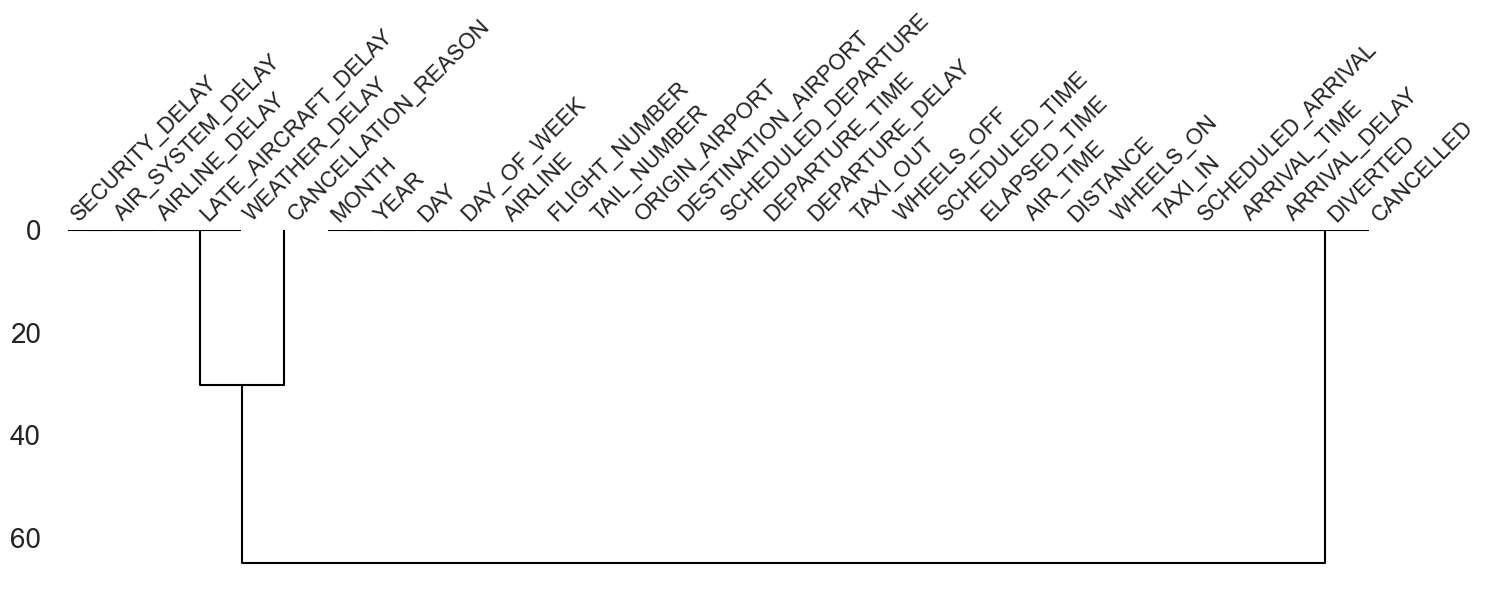

In [41]:
msno.dendrogram(vols.sample(5000), figsize=(15,6))

# Ajuster la mise en page pour tout voir correctement
plt.tight_layout()

# Enregistrer le graphique
plt.savefig('missdendo.png')

###### Le dendrogramme met en évidence une segmentation claire des variables selon leur structure de valeurs manquantes, distinguant un cluster de variables relatives aux causes de retard, caractérisées par des absences structurelles et non aléatoires, et un ensemble de variables opérationnelles largement renseignées, ce qui justifie l’exclusion du premier groupe dans une logique de prédiction du retard à l’arrivée.

In [43]:
# suppression des colonnes non pertinentes

var_to_drop = [
    # Variables ex post / fuite d'information
    'ARRIVAL_TIME',
    'WHEELS_ON',
    'TAXI_IN',
    'ELAPSED_TIME',
    'AIR_TIME',
    'DIVERTED',
    'CANCELLED',

    # Variables causes de retard (MNAR, a posteriori)
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY',
    'CANCELLATION_REASON',

    # Variables redondantes / non généralisables
    'WHEELS_OFF',        # redondant avec TAXI_OUT
    'FLIGHT_NUMBER',
    'TAIL_NUMBER'
]

vols.drop(columns=var_to_drop, errors='ignore', inplace=True)
vols.head(5)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY
0,2015,1,1,4,AS,ANC,SEA,00:05:00,23:54:00,-11.000,21.000,205.000,1448,04:30:00,-22.000
1,2015,1,1,4,AA,LAX,PBI,00:10:00,00:02:00,-8.000,12.000,280.000,2330,07:50:00,-9.000
2,2015,1,1,4,US,SFO,CLT,00:20:00,00:18:00,-2.000,16.000,286.000,2296,08:06:00,5.000
3,2015,1,1,4,AA,LAX,MIA,00:20:00,00:15:00,-5.000,15.000,285.000,2342,08:05:00,-9.000
4,2015,1,1,4,AS,SEA,ANC,00:25:00,00:24:00,-1.000,11.000,235.000,1448,03:20:00,-21.000


In [45]:
# Calcul du nombre de valeurs manquantes par variable
missing_counts = vols.isnull().sum()

# Calcul du pourcentage de valeurs présentes
present_percentage = (vols.shape[0] - missing_counts) / vols.shape[0] * 100

# Création du DataFrame final
missing_stats = pd.DataFrame({
    'variable': missing_counts.index,
    'missing values': missing_counts.values,
    'filling factor (%)': present_percentage.values
})

# Tri par taux de remplissage croissant (comme dans l'autre code)
missing_stats = missing_stats.sort_values(
    by='filling factor (%)',
    ascending=True
).reset_index(drop=True)

missing_stats


,variable,missing values,filling factor (%)
0,YEAR,0,100.000
1,MONTH,0,100.000
2,DAY,0,100.000
3,DAY_OF_WEEK,0,100.000
4,AIRLINE,0,100.000
5,ORIGIN_AIRPORT,0,100.000
6,DESTINATION_AIRPORT,0,100.000
7,SCHEDULED_DEPARTURE,0,100.000
8,DEPARTURE_TIME,0,100.000
9,DEPARTURE_DELAY,0,100.000


In [47]:
vols.shape

(5714008, 15)

###### Pour simplifier l’analyse et permettre l’application de modèles de classification supervisée, nous définissons une variable binaire indiquant si un vol est retardé ou non. Un vol est considéré comme retardé si le retard à l'arrivé (ARRIVAL_DELAY) est strictement positif, et non retardé sinon (vol à l’heure ou en avance). Cette approche permet de transformer le problème en une tâche de classification binaire, tout en conservant l’ensemble des observations et en respectant la distribution réelle des retards.

In [50]:
# ## 1.4 Création des Dictionnaires de Correspondance

# %%
print("\n3. Création des dictionnaires de correspondance:")
print("-" * 40)

# Dictionnaire pour les noms de compagnies aériennes
Airline_Names = {}
for i in range(len(airlines)):
    Airline_Names[airlines["IATA_CODE"][i]] = airlines["AIRLINE"][i]
print(f"Noms de compagnies chargés: {len(Airline_Names)}")

# Dictionnaire pour les noms d'aéroports
Airport_Names = {}
for i in range(len(airports)):
    Airport_Names[airports["IATA_CODE"][i]] = airports["AIRPORT"][i]
print(f"Noms d'aéroports chargés: {len(Airport_Names)}")

# Dictionnaire pour les noms de villes
City_Names = {}
for i in range(len(airports)):
    City_Names[airports["IATA_CODE"][i]] = airports["CITY"][i]
print(f"Noms de villes chargés: {len(City_Names)}")

# %% [markdown]
# ## 1.5 Fusion des Datasets

# %%
print("\n4. Fusion des datasets:")
print("-" * 40)

# Création du DataFrame principal
df = pd.DataFrame()



3. Création des dictionnaires de correspondance:
----------------------------------------
Noms de compagnies chargés: 14
Noms d'aéroports chargés: 322
Noms de villes chargés: 322

4. Fusion des datasets:
----------------------------------------


In [52]:
df.shape

(0, 0)

In [54]:
# ## 1.5 Fusion des Datasets

# %%
print("\n4. Fusion des datasets:")
print("-" * 40)

# Création du DataFrame principal
df = pd.DataFrame()

# Informations de date et jour
df['DATE'] = pd.to_datetime(vols[['YEAR', 'MONTH', 'DAY']])
df['DAY'] = vols["DAY_OF_WEEK"]  # jour de la semaine
df['MONTH'] = vols['MONTH']

# Informations sur la compagnie aérienne
df['AIRLINE'] = vols["AIRLINE"]
df['AIRLINE_NAME'] = vols['AIRLINE'].map(Airline_Names)

# Informations sur l'origine
df['ORIGIN'] = vols['ORIGIN_AIRPORT']
df['ORIGIN_AIRPORT_NAME'] = vols['ORIGIN_AIRPORT'].map(Airport_Names)
df['ORIGIN_CITY'] = vols['ORIGIN_AIRPORT'].map(City_Names)

# Informations sur la destination
df['DESTINATION'] = vols['DESTINATION_AIRPORT']
df['DESTINATION_AIRPORT_NAME'] = vols['DESTINATION_AIRPORT'].map(Airport_Names)
df['DESTINATION_CITY'] = vols['DESTINATION_AIRPORT'].map(City_Names)

# Informations sur le vol
df['DISTANCE'] = vols['DISTANCE']
df['TAXI_OUT'] = vols['TAXI_OUT']
df['DEPARTURE_DELAY'] = vols['DEPARTURE_DELAY']
df['ARRIVAL_DELAY'] = vols['ARRIVAL_DELAY']
df['SCHEDULED_DEPARTURE']=vols['SCHEDULED_DEPARTURE']
df['SCHEDULED_ARRIVAL'] = vols['SCHEDULED_ARRIVAL']

print("Fusion terminée, DataFrame df créé avec succès !")
print(f"Nombre de vols : {len(df)}")


4. Fusion des datasets:
----------------------------------------
Fusion terminée, DataFrame df créé avec succès !
Nombre de vols : 5714008


In [55]:
df.head()

,DATE,DAY,MONTH,AIRLINE,AIRLINE_NAME,ORIGIN,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,DESTINATION,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DISTANCE,TAXI_OUT,DEPARTURE_DELAY,ARRIVAL_DELAY,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL
0,2015-01-01,4,1,AS,Alaska Airlines Inc.,ANC,Ted Stevens Anchorage International Airport,Anchorage,SEA,Seattle-Tacoma International Airport,Seattle,1448,21.000,-11.000,-22.000,00:05:00,04:30:00
1,2015-01-01,4,1,AA,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,PBI,Palm Beach International Airport,West Palm Beach,2330,12.000,-8.000,-9.000,00:10:00,07:50:00
2,2015-01-01,4,1,US,US Airways Inc.,SFO,San Francisco International Airport,San Francisco,CLT,Charlotte Douglas International Airport,Charlotte,2296,16.000,-2.000,5.000,00:20:00,08:06:00
3,2015-01-01,4,1,AA,American Airlines Inc.,LAX,Los Angeles International Airport,Los Angeles,MIA,Miami International Airport,Miami,2342,15.000,-5.000,-9.000,00:20:00,08:05:00
4,2015-01-01,4,1,AS,Alaska Airlines Inc.,SEA,Seattle-Tacoma International Airport,Seattle,ANC,Ted Stevens Anchorage International Airport,Anchorage,1448,11.000,-1.000,-21.000,00:25:00,03:20:00


###### Pour avoir une vue d'ensemble de la zone géographique couverte par cet ensemble de données, nous pouvons tracer la localisation des aéroports et indiquer le nombre de vols enregistrés dans chacun d'eux au cours de l'année 2015.

###### Comme mentionné précédemment, dans la table flight.csv, la variable airline correspond aux abréviations des compagnies aériennes.
###### Afin d’obtenir l’intitulé complet de chaque compagnie, il est nécessaire de se référer au fichier airlines.csv, qui fournit la correspondance entre abréviations et noms complets.

# EDA

## 2.1 Analyse UNIVARIÉE

### 2.1.1 Distribution des retards à l’arrivée (CIBLE)

Statistiques ARRIVAL_DELAY
count   5714008.000
mean          4.407
std          39.271
min         -87.000
25%         -13.000
50%          -5.000
75%           8.000
max        1971.000
Name: ARRIVAL_DELAY, dtype: float64


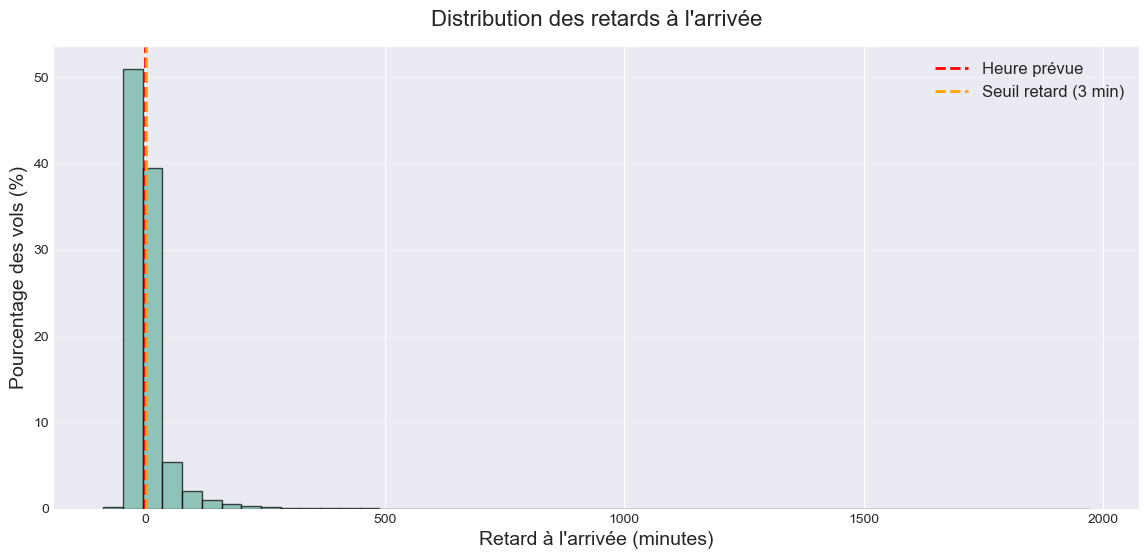

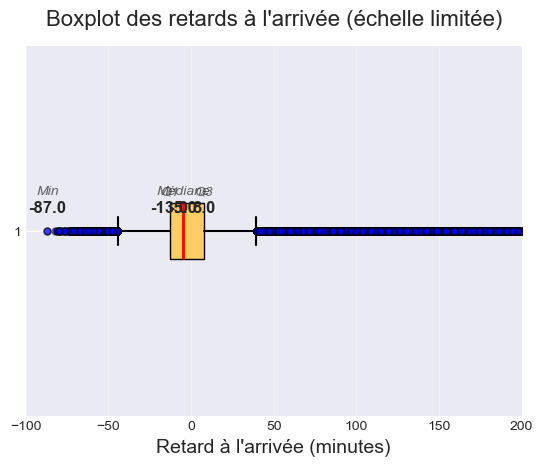

In [63]:
# Statistiques descriptives
print("Statistiques ARRIVAL_DELAY")
print(df['ARRIVAL_DELAY'].describe())

# Distribution en pourcentages
plt.figure(figsize=(14, 6))
weights = np.ones_like(df['ARRIVAL_DELAY']) / len(df['ARRIVAL_DELAY']) * 100
plt.hist(df['ARRIVAL_DELAY'], bins=50, edgecolor='black', color='#69b3a2', alpha=0.7, weights=weights)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Heure prévue')
plt.axvline(x=3, color='orange', linestyle='--', linewidth=2, label='Seuil retard (3 min)')
plt.xlabel("Retard à l'arrivée (minutes)", fontsize=14)
plt.ylabel("Pourcentage des vols (%)", fontsize=14)
plt.title("Distribution des retards à l'arrivée", fontsize=16, pad=15)
plt.grid(True, alpha=0.3, axis='y')
plt.legend(fontsize=12)
plt.gca().get_yaxis().get_major_formatter().set_scientific(False)
plt.savefig('histocible.png')
plt.show()

# Boxplot des retards
# Limiter l'axe X pour lisibilité (ex: -200 à 300 minutes)
x_min, x_max = -100, 200
# Si vous voulez un boxplot simple pour l'ensemble des retards
dftest= df['ARRIVAL_DELAY'].dropna()

# Boxplot horizontal
box = plt.boxplot(dftest, vert=False, patch_artist=True,
                  boxprops=dict(facecolor='#FFCC66', color='black'),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5),
                  flierprops=dict(marker='o', markerfacecolor='blue', markersize=5, alpha=0.5))

plt.xlabel("Retard à l'arrivée (minutes)", fontsize=14)
plt.title("Boxplot des retards à l'arrivée (échelle limitée)", fontsize=16, pad=15)
plt.grid(True, alpha=0.3, axis='x')
plt.xlim(x_min, x_max)

# Calculer les quantiles
Q1 = np.percentile(dftest, 25)
median = np.percentile(dftest, 50)
Q3 = np.percentile(dftest, 75)
min_val = dftest.min()

# Annoter les quantiles visibles dans la plage
for q, label in zip([min_val, Q1, median, Q3], ['Min', 'Q1', 'Médiane', 'Q3']):
    plt.text(q, 1.05, f'{q:.1f}', ha='center', fontsize=12, fontweight='bold')
    plt.text(q, 1.1, label, ha='center', fontsize=10, fontstyle='italic', alpha=0.7)


plt.show()

### 2.1.2 Distribution des variables numériques explicatives

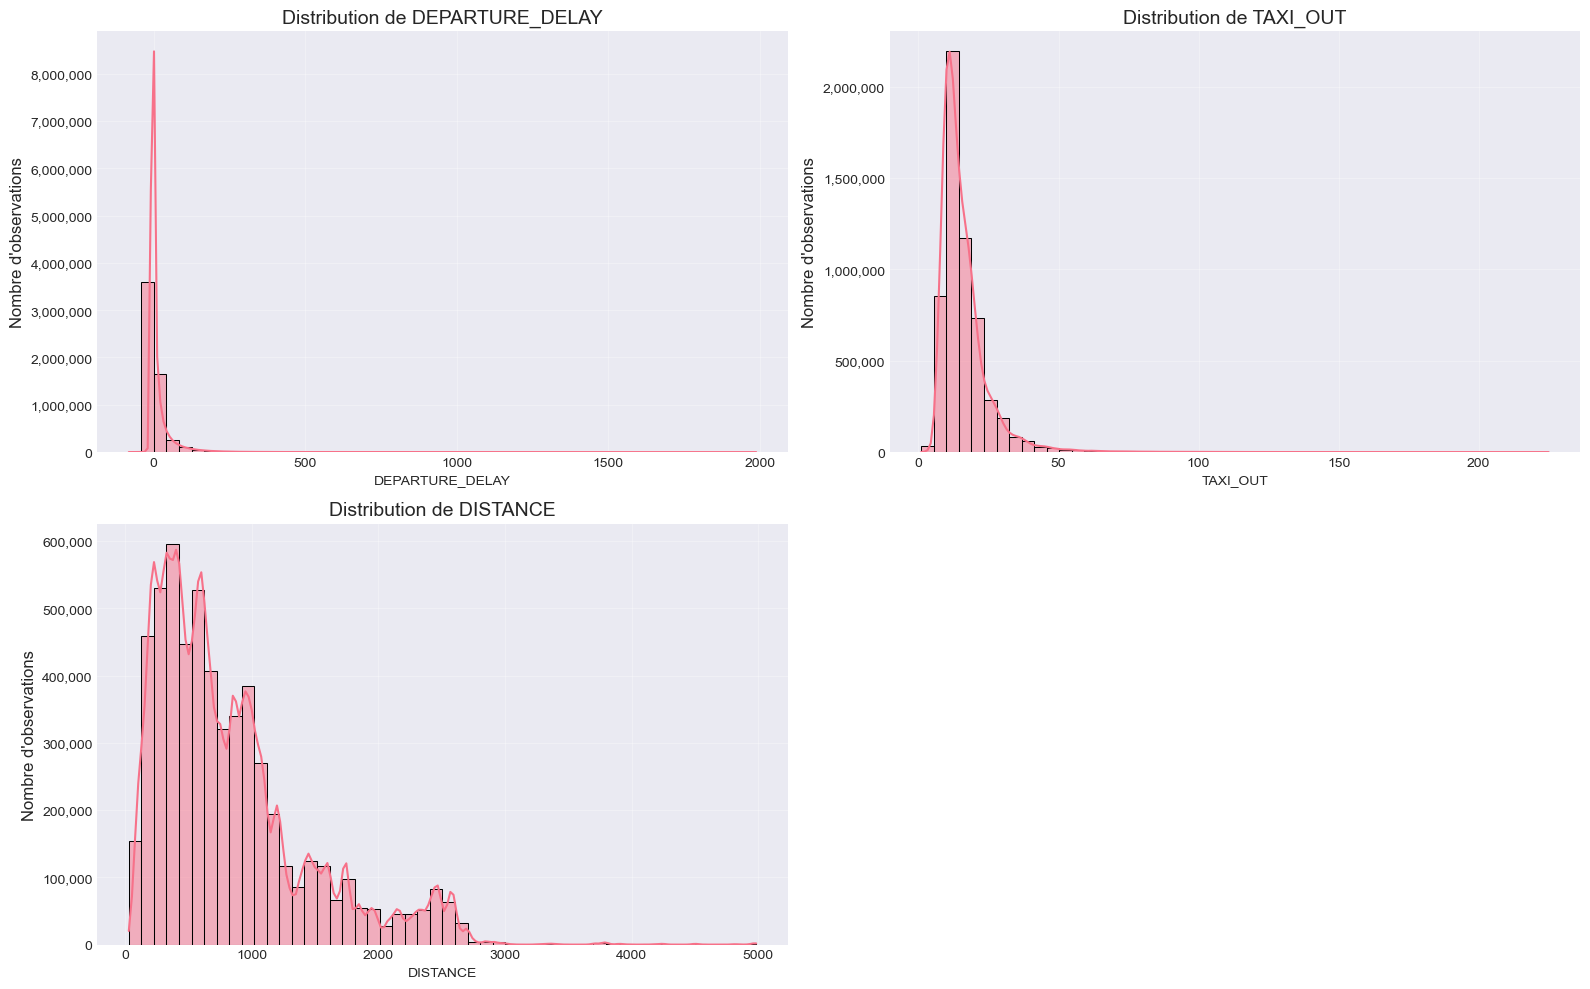

In [137]:

num_vars = ['DEPARTURE_DELAY', 'TAXI_OUT', 'DISTANCE']

plt.figure(figsize=(16, 10))

for i, var in enumerate(num_vars, 1):
    ax = plt.subplot(2, 2, i)
    
    sns.histplot(df[var], bins=50, kde=True)
    ax.set_title(f'Distribution de {var}', fontsize=14)
    ax.set_ylabel("Nombre d'observations", fontsize=12)
    
    # Forcer affichage normal (pas exponentiel)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


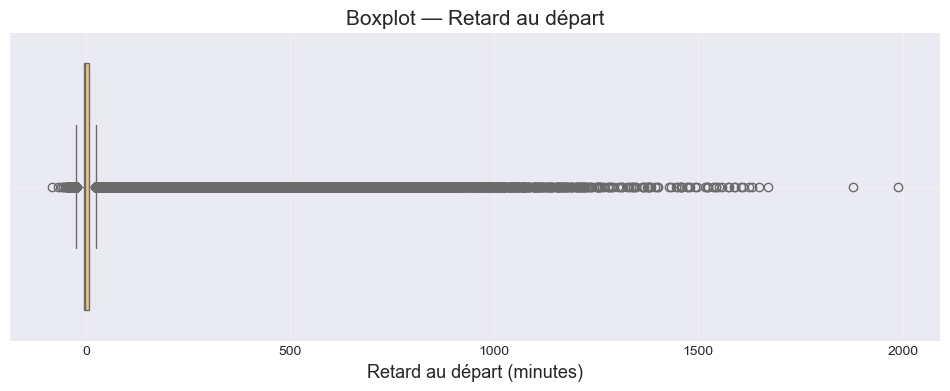

In [143]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=df['DEPARTURE_DELAY'],
            color='#FFCC66')

plt.xlabel("Retard au départ (minutes)", fontsize=13)
plt.title("Boxplot — Retard au départ", fontsize=15)
plt.grid(alpha=0.3)
plt.show()


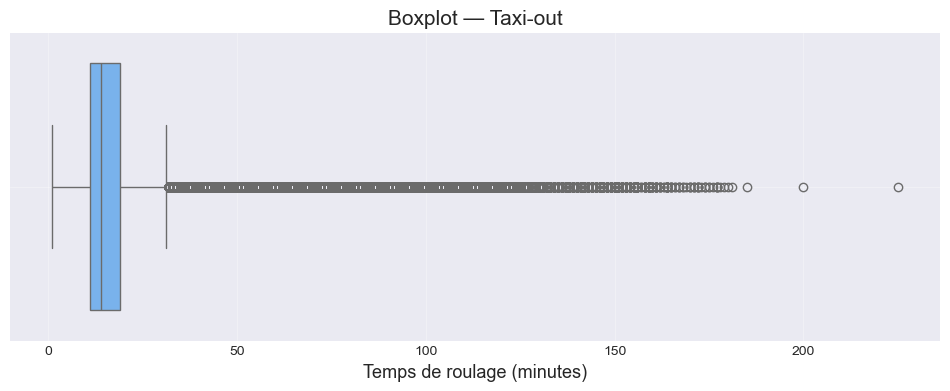

In [145]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=df['TAXI_OUT'],
            color='#66B2FF')

plt.xlabel("Temps de roulage (minutes)", fontsize=13)
plt.title("Boxplot — Taxi-out", fontsize=15)
plt.grid(alpha=0.3)
plt.show()


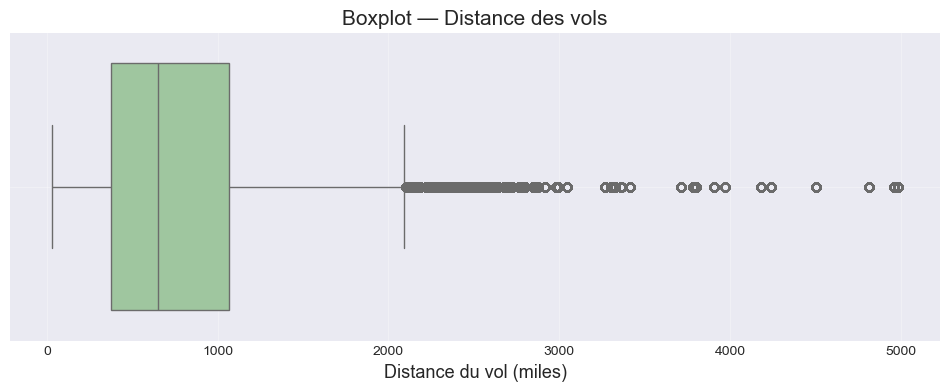

In [147]:
plt.figure(figsize=(12, 4))

sns.boxplot(x=df['DISTANCE'],
            color='#99CC99')

plt.xlabel("Distance du vol (miles)", fontsize=13)
plt.title("Boxplot — Distance des vols", fontsize=15)
plt.grid(alpha=0.3)
plt.show()


In [149]:
# Liste des variables numériques concernées par les boxplots
num_vars = ['DEPARTURE_DELAY', 'TAXI_OUT', 'DISTANCE']

# Copie du dataframe pour garder une version propre
df_wins = df.copy()

for var in num_vars:
    Q1 = df_wins[var].quantile(0.25)
    Q3 = df_wins[var].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Winsorisation
    df_wins[var] = df_wins[var].clip(lower=lower_bound, upper=upper_bound)

    print(
        f"{var} | bornes IQR : [{lower_bound:.2f} ; {upper_bound:.2f}]"
    )

print("Winsorisation terminée — aucune observation supprimée.")


DEPARTURE_DELAY | bornes IQR : [-23.00 ; 25.00]
TAXI_OUT | bornes IQR : [-1.00 ; 31.00]
DISTANCE | bornes IQR : [-665.00 ; 2103.00]
Winsorisation terminée — aucune observation supprimée.


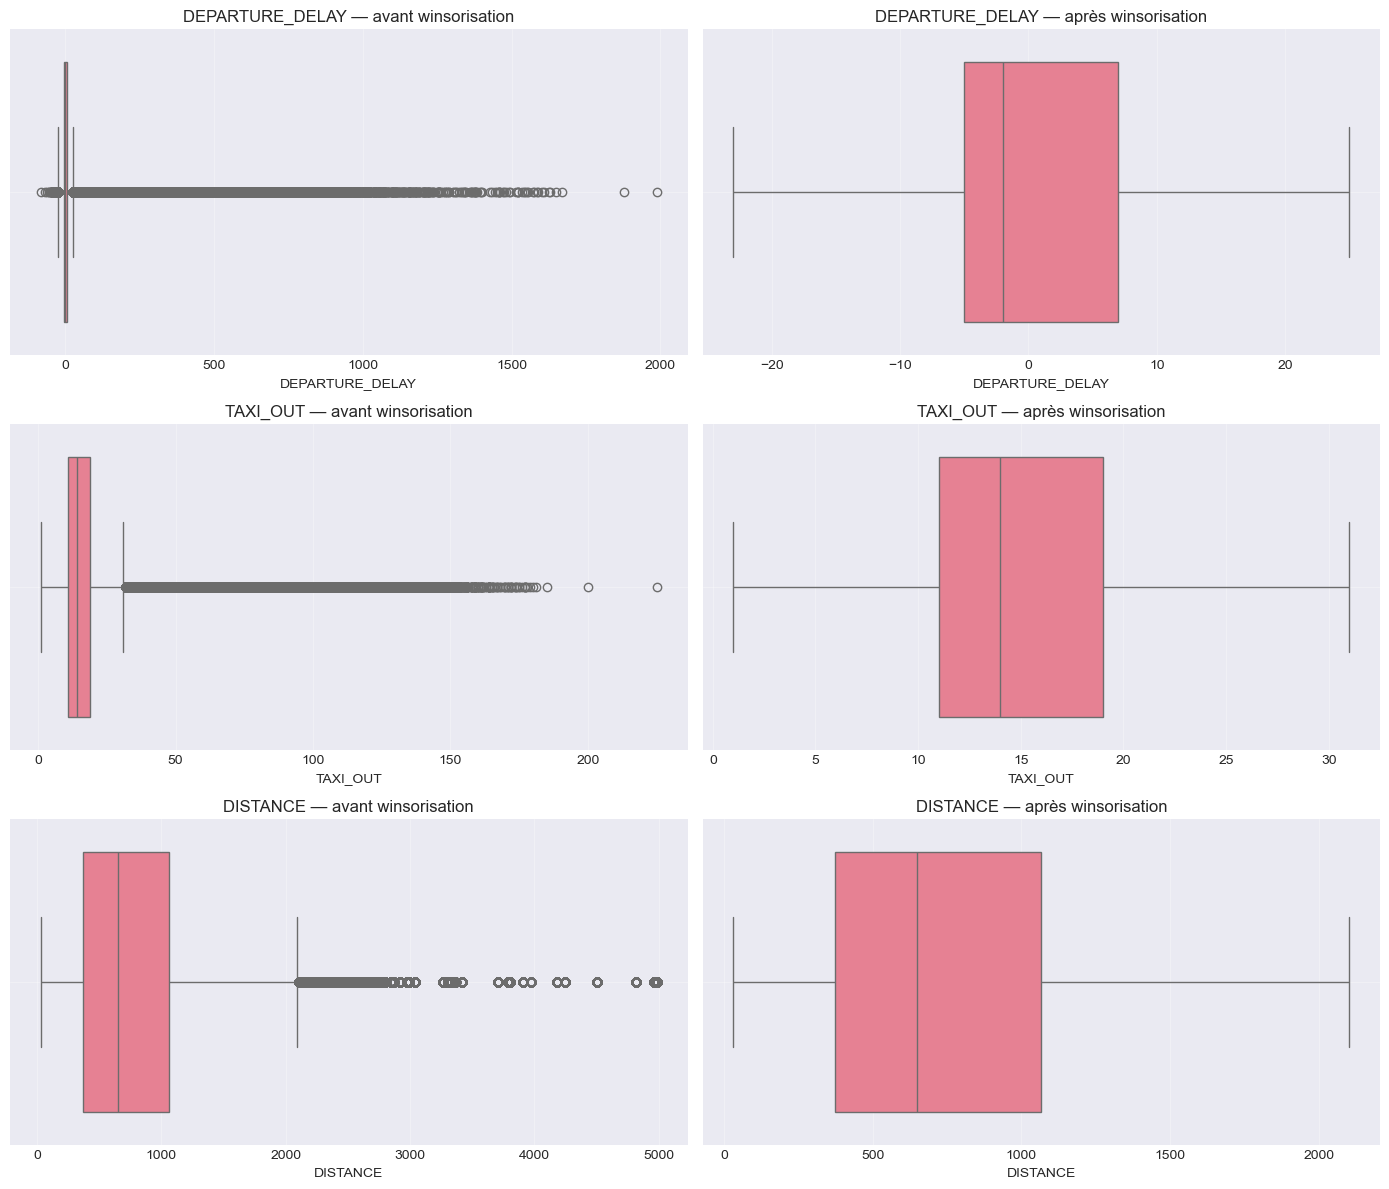

In [151]:
fig, axes = plt.subplots(len(num_vars), 2, figsize=(14, 4 * len(num_vars)))

for i, var in enumerate(num_vars):
    # Avant
    sns.boxplot(x=df[var], ax=axes[i, 0])
    axes[i, 0].set_title(f"{var} — avant winsorisation")
    axes[i, 0].grid(alpha=0.3)

    # Après
    sns.boxplot(x=df_wins[var], ax=axes[i, 1])
    axes[i, 1].set_title(f"{var} — après winsorisation")
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 2.1.3 Distribution de la cible binaire (retard / pas retard)

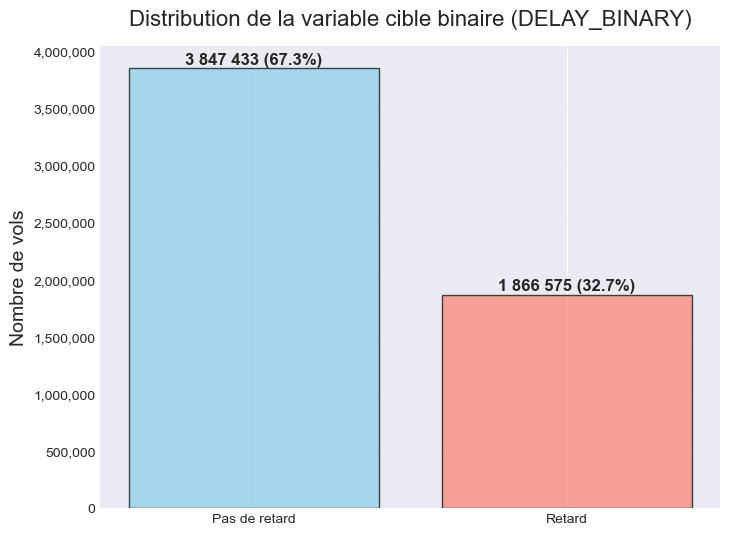

Répartition des classes :
DELAY_BINARY
0   67.330
1   32.670
Name: proportion, dtype: float64


In [154]:


# Création de la variable binaire
df['DELAY_BINARY'] = (df['ARRIVAL_DELAY'] >= 3).astype(int)

# Comptage des classes
counts = df['DELAY_BINARY'].value_counts().sort_index()
percentages = df['DELAY_BINARY'].value_counts(normalize=True).sort_index() * 100

# Graphique
plt.figure(figsize=(8,6))
bars = plt.bar(['Pas de retard', 'Retard'], counts, color=['skyblue', 'salmon'], edgecolor='k', alpha=0.7)

# Ajouter les valeurs et pourcentages au-dessus des barres
for bar, count, perc in zip(bars, counts, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01, 
             f'{count:,} ({perc:.1f}%)'.replace(',', ' '), 
             ha='center', fontsize=12, fontweight='bold')

# Paramètres axes
plt.ylabel("Nombre de vols", fontsize=14)
plt.title("Distribution de la variable cible binaire (DELAY_BINARY)", fontsize=16, pad=15)
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))  # nombres sans exposant
plt.show()

# Afficher les pourcentages en console aussi
print("Répartition des classes :")
print(percentages.round(2))


### 2.1.4 Distribution temporelle - Fréquence des vols

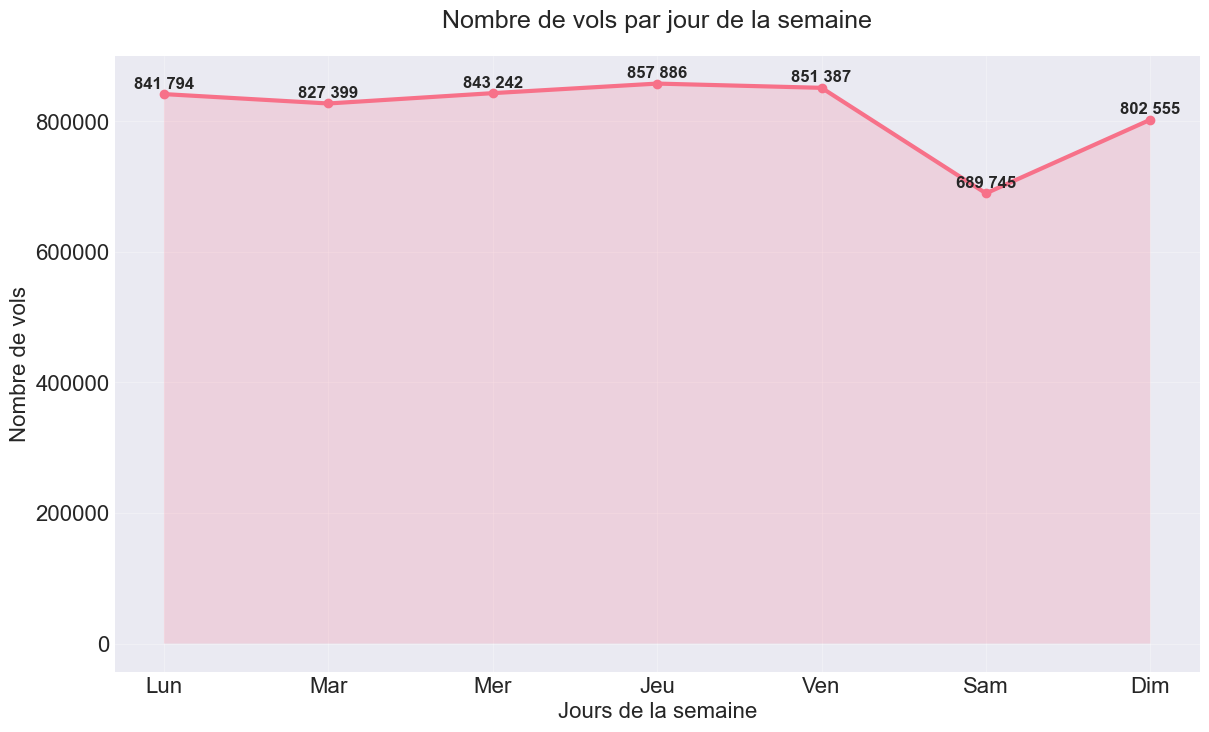

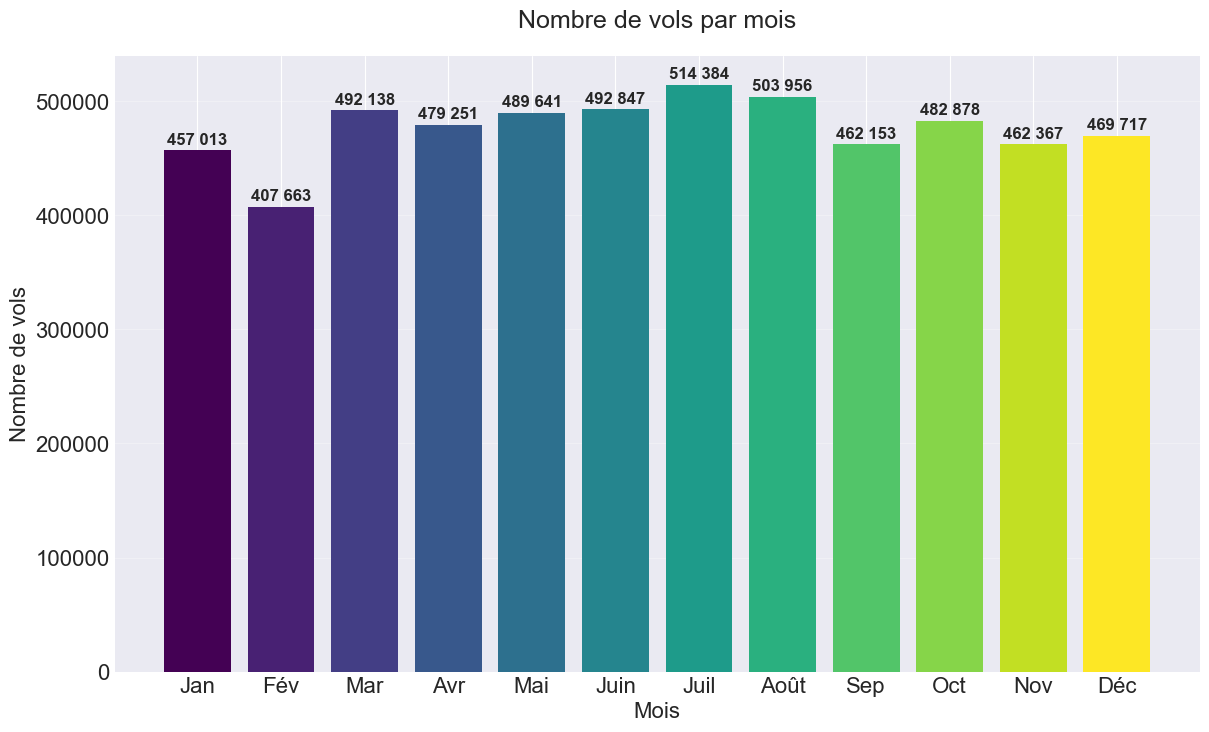

In [157]:
# Fréquence des Vols par Jour de la Semaine
daysOfWeek = vols['DAY_OF_WEEK']
dayCounts = dict(daysOfWeek.value_counts())
dayFreq = {day: dayCounts[day] for day in sorted(dayCounts)}

jours_fr = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
flightFreq = list(dayFreq.values())

plt.figure(figsize=(14, 8))
plt.plot(jours, flightFreq, marker='o', linewidth=3)
plt.xlabel("Jours de la semaine", fontsize=16)
plt.ylabel("Nombre de vols", fontsize=16)
plt.title("Nombre de vols par jour de la semaine", fontsize=18, pad=20)
plt.tick_params(labelsize=16)
plt.grid(True, alpha=0.3)
plt.fill_between(jours, flightFreq, alpha=0.2)

# Ajouter des annotations
for i, (jour, freq) in enumerate(zip(jours_fr, flightFreq)):
    plt.text(i, freq + max(flightFreq)*0.01, f'{freq:,}'.replace(",", " "), 
             ha='center', fontsize=12, fontweight='bold')
plt.show()

# Fréquence des Vols par Mois
months = df['MONTH']
monthCounts = dict(months.value_counts())
monthFreq = {month: monthCounts[month] for month in sorted(monthCounts)}

flightFreq = list(monthFreq.values())
monthsArr = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
             'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

plt.figure(figsize=(14, 8))
bars = plt.bar(monthsArr, flightFreq, color=plt.cm.viridis(np.linspace(0, 1, len(monthsArr))))
plt.xlabel("Mois", fontsize=16)
plt.ylabel("Nombre de vols", fontsize=16)
plt.title("Nombre de vols par mois", fontsize=18, pad=20)
plt.tick_params(labelsize=16)
plt.grid(True, alpha=0.3, axis='y')

# Ajouter des valeurs sur les barres
for bar, freq in zip(bars, flightFreq):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(flightFreq)*0.01,
             f'{freq:,}'.replace(",", " "), ha='center', fontsize=12, fontweight='bold')
plt.show()

### 2.1.5 Distribution par compagnie aérienne

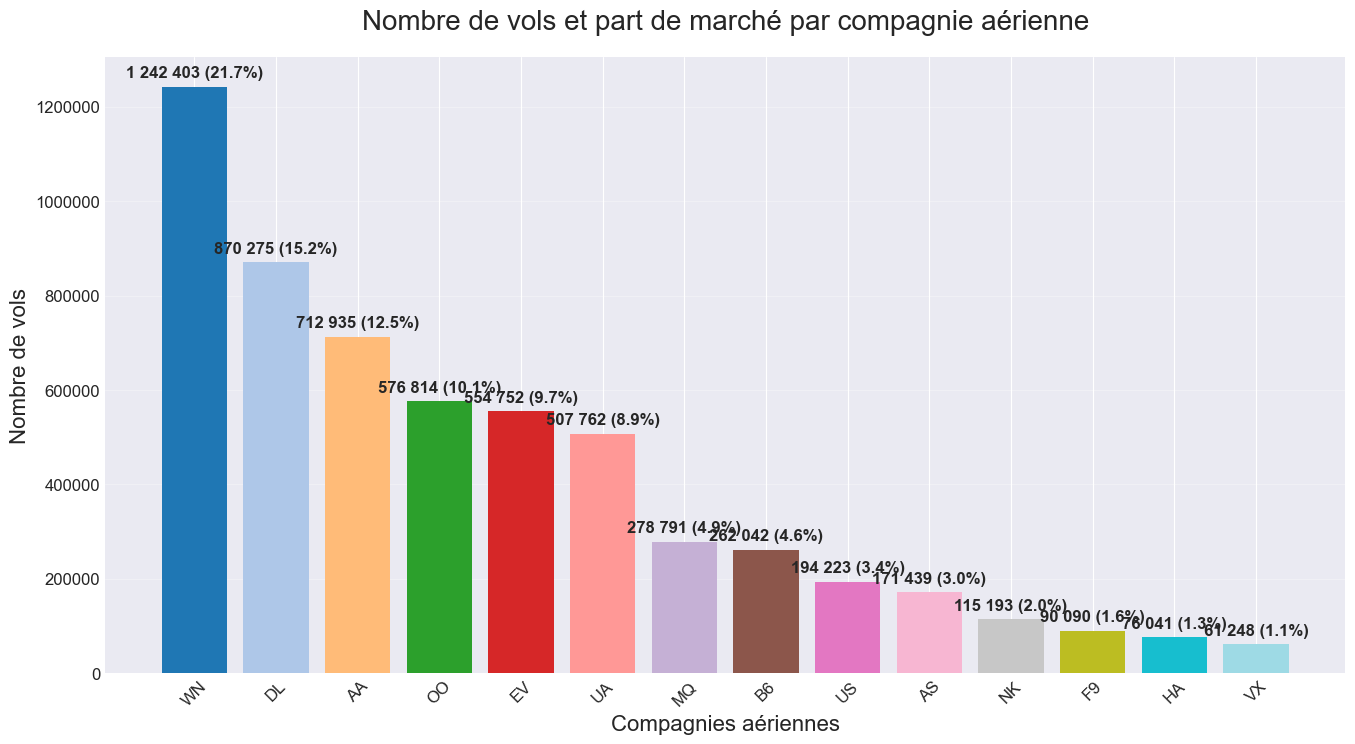

In [160]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Part de Trafic Aérien des Compagnies

# Compter le nombre de vols par compagnie
airline_counts = df['AIRLINE'].value_counts()
airline_names = airline_counts.index  # codes des compagnies
total_flights = airline_counts.sum()

# Calculer les pourcentages
airline_percent = 100 * airline_counts / total_flights

# Créer un colormap pour des couleurs différentes
colors = cm.tab20(np.linspace(0, 1, len(airline_counts)))

# Création du graphique en barres
fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(airline_names, airline_counts, color=colors)

# Ajouter annotations : nombre de vols + pourcentage
for bar, count, perc in zip(bars, airline_counts, airline_percent):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        height + max(airline_counts)*0.01,
        f'{int(count):,} ({perc:.1f}%)'.replace(",", " "),  # nombre + pourcentage
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# Titres et axes
ax.set_xlabel("Compagnies aériennes", fontsize=16)
ax.set_ylabel("Nombre de vols", fontsize=16)
ax.set_title("Nombre de vols et part de marché par compagnie aérienne", fontsize=20, pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Forcer l’axe Y à afficher des nombres entiers (pas exponentiels)
ax.get_yaxis().get_major_formatter().set_scientific(False)

ax.grid(axis='y', alpha=0.3)

plt.show()


## 2.2 Analyse BIVARIÉE

### 2.2.1 Retard à l’arrivée vs variables numériques

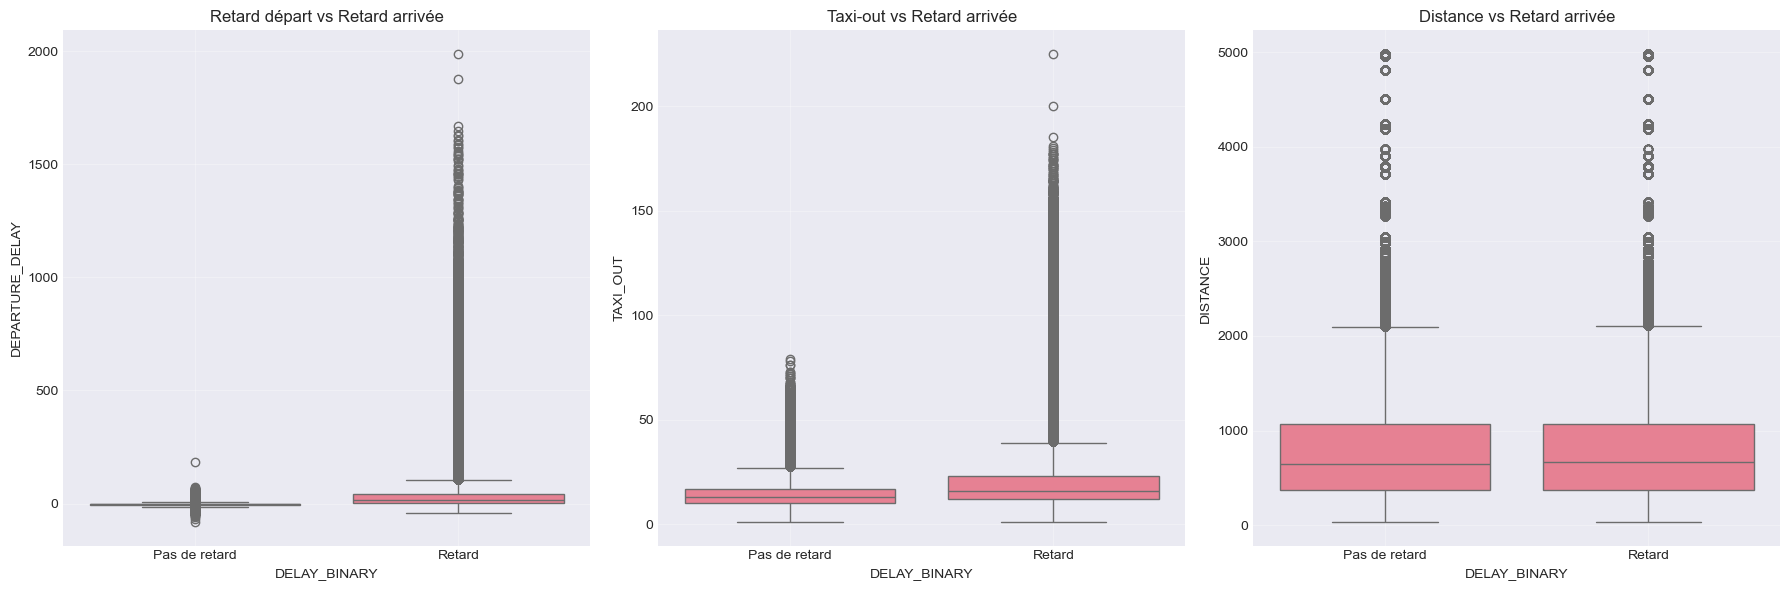

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='DELAY_BINARY', y='DEPARTURE_DELAY', data=df, ax=axes[0])
axes[0].set_title("Retard départ vs Retard arrivée")

sns.boxplot(x='DELAY_BINARY', y='TAXI_OUT', data=df, ax=axes[1])
axes[1].set_title("Taxi-out vs Retard arrivée")

sns.boxplot(x='DELAY_BINARY', y='DISTANCE', data=df, ax=axes[2])
axes[2].set_title("Distance vs Retard arrivée")

for ax in axes:
    ax.set_xticklabels(['Pas de retard', 'Retard'])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2.2 Retards moyens par compagnie

Top 5 des compagnies avec les plus grands retards moyens:
                                 min      max   count   mean
AIRLINE_NAME                                                
Spirit Air Lines             -60.000  833.000  115193 14.470
Frontier Airlines Inc.       -73.000 1101.000   90090 12.500
JetBlue Airways              -76.000 1002.000  262042  6.680
Atlantic Southeast Airlines  -64.000 1223.000  554752  6.590
American Eagle Airlines Inc. -63.000 1528.000  278791  6.460

Top 5 des compagnies avec les plus petits retards moyens:
                           min      max   count   mean
AIRLINE_NAME                                          
US Airways Inc.        -87.000  750.000  194223  3.710
American Airlines Inc. -87.000 1971.000  712935  3.450
Hawaiian Airlines Inc. -67.000 1467.000   76041  2.020
Delta Air Lines Inc.   -79.000 1274.000  870275  0.190
Alaska Airlines Inc.   -82.000  950.000  171439 -0.980


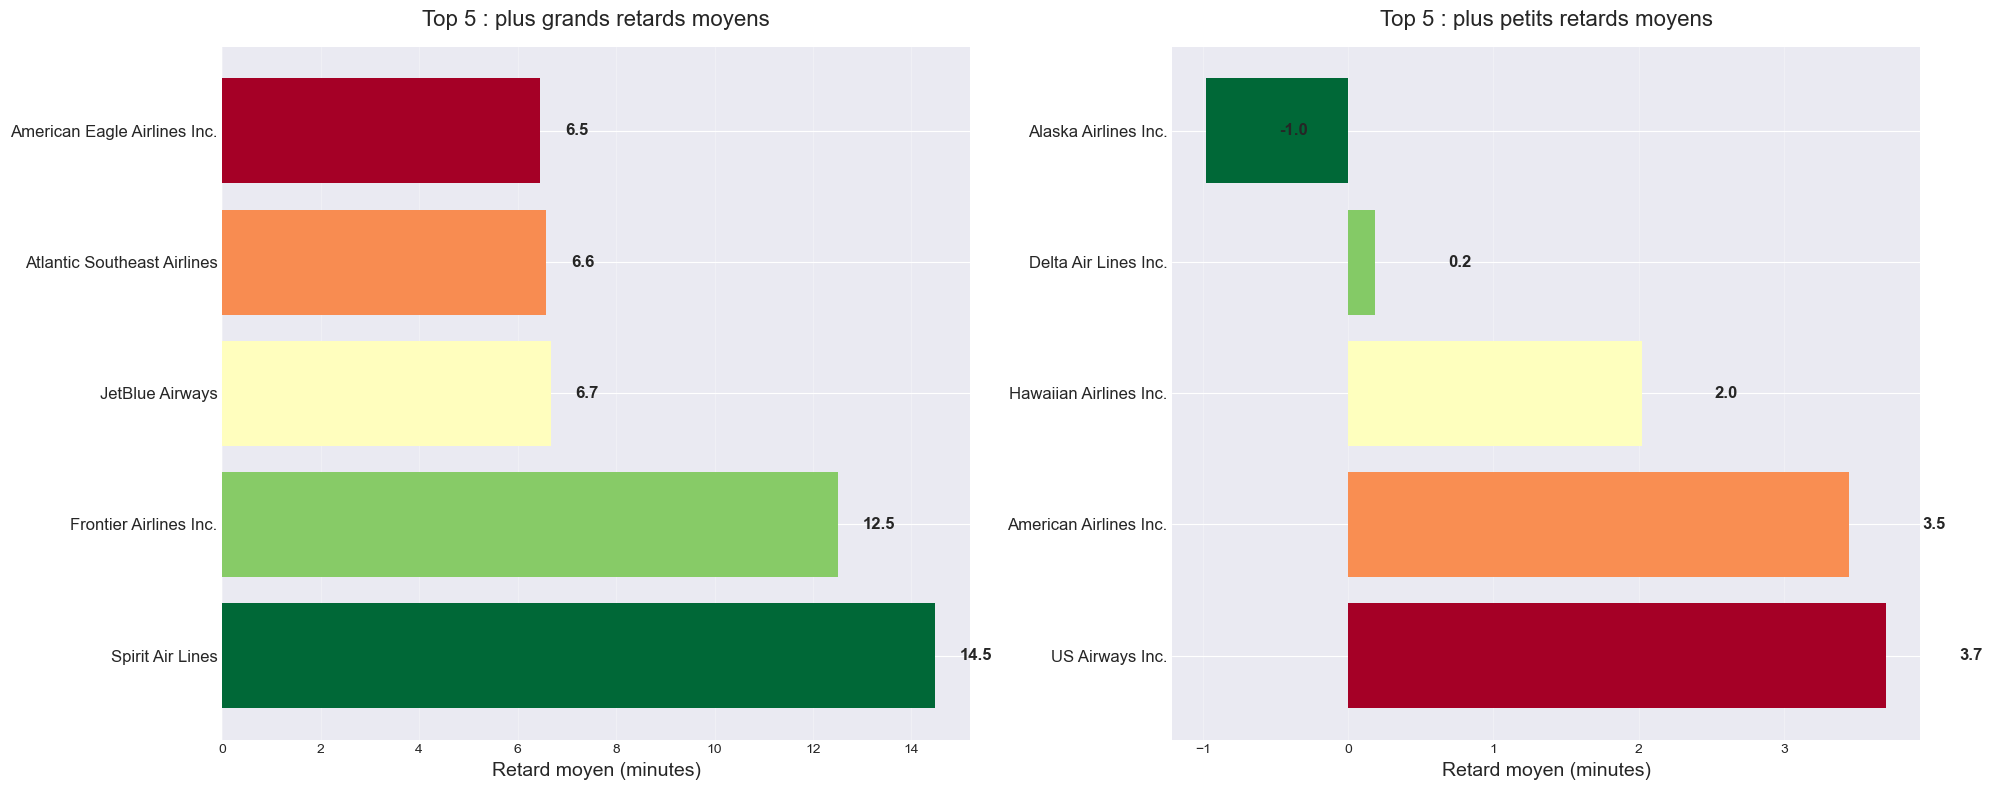

In [181]:
# Calculer les statistiques de retard à l'arrivée par compagnie
Airline_Stats = df.groupby('AIRLINE_NAME')['ARRIVAL_DELAY'] \
                  .agg(['min', 'max', 'count', 'mean']) \
                  .sort_values('mean', ascending=False)

# Top 5 des compagnies avec les plus grands retards moyens
top5_max = Airline_Stats.head(5)
# Top 5 des compagnies avec les plus petits retards moyens
top5_min = Airline_Stats.tail(5)

# Affichage console
print("Top 5 des compagnies avec les plus grands retards moyens:")
print(top5_max.round(2))
print("\nTop 5 des compagnies avec les plus petits retards moyens:")
print(top5_min.round(2))

# Visualisation côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharex=False)

# --- Graphique des plus grands retards ---
bars1 = ax1.barh(range(len(top5_max)), 
                 top5_max['mean'].values,
                 color=plt.cm.RdYlGn_r(np.linspace(0, 1, 5)))
ax1.set_yticks(range(len(top5_max)))
ax1.set_yticklabels(top5_max.index, fontsize=12)
ax1.set_xlabel("Retard moyen (minutes)", fontsize=14)
ax1.set_title("Top 5 : plus grands retards moyens", fontsize=16, pad=15)
ax1.grid(True, alpha=0.3, axis='x')

for i, mean_val in enumerate(top5_max['mean'].values):
    ax1.text(mean_val + 0.5, i, f'{mean_val:.1f}', va='center', fontsize=12, fontweight='bold')

# --- Graphique des plus petits retards ---
bars2 = ax2.barh(range(len(top5_min)), 
                 top5_min['mean'].values,
                 color=plt.cm.RdYlGn(np.linspace(0, 1, 5)))
ax2.set_yticks(range(len(top5_min)))
ax2.set_yticklabels(top5_min.index, fontsize=12)
ax2.set_xlabel("Retard moyen (minutes)", fontsize=14)
ax2.set_title("Top 5 : plus petits retards moyens", fontsize=16, pad=15)
ax2.grid(True, alpha=0.3, axis='x')

for i, mean_val in enumerate(top5_min['mean'].values):
    ax2.text(mean_val + 0.5, i, f'{mean_val:.1f}', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

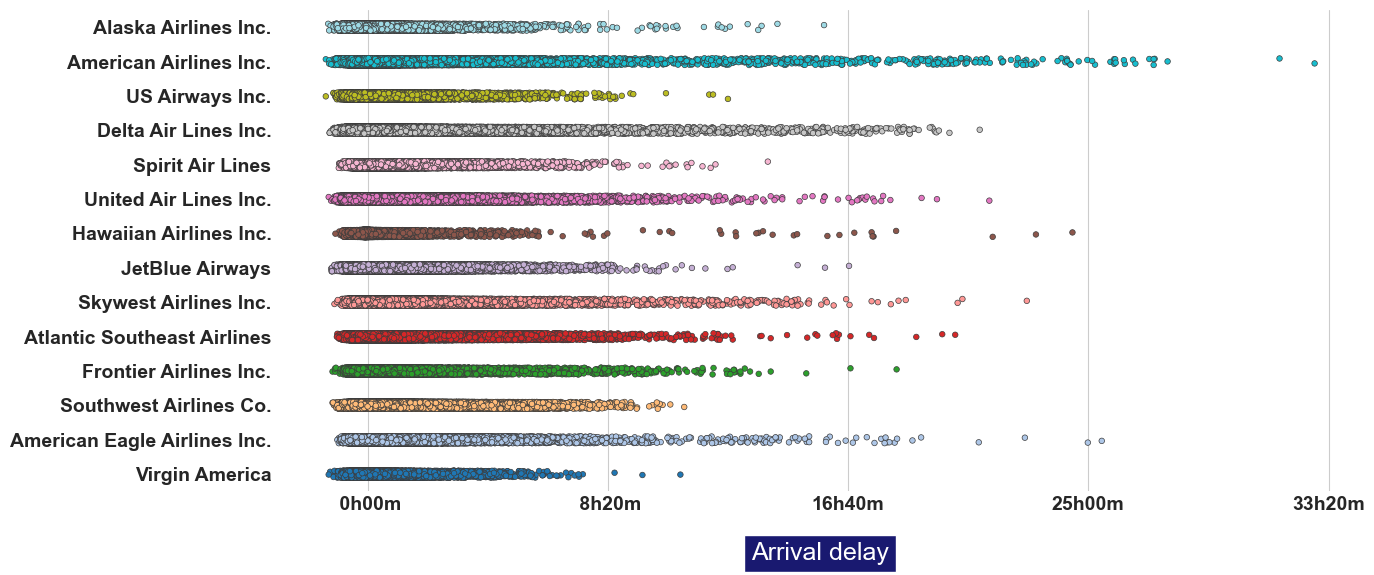

In [185]:
# STRIPPLOT : Distribution détaillée des retards par compagnie
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
# Visualisation striplot 
# Configuration de la police (sans warnings)
font = {'family' : 'sans-serif', 'weight' : 'bold', 'size' : 15}
mpl.rc('font', **font)
sns.set_style("whitegrid")
# Sous-ensemble des colonnes nécessaires
df2 = df.loc[:, ['AIRLINE_NAME', 'ARRIVAL_DELAY']].copy()

# Pourcentage du total de vols
Airline_Stats['pct'] = Airline_Stats['count'] / Airline_Stats['count'].sum() * 100

# Tri par nombre de vols
Airline_Stats = Airline_Stats.sort_values('count', ascending=False)
# Palette inversée pour correspondance visuelle
colors_strip = colors[::-1]

plt.figure(figsize=(14,6))
ax = sns.stripplot(y="AIRLINE_NAME", x="ARRIVAL_DELAY", size=4, palette=colors_strip,
                   data=df2, linewidth=0.5, jitter=True)
plt.setp(ax.get_xticklabels(), fontsize=14)
plt.setp(ax.get_yticklabels(), fontsize=14)

# Conversion minutes → H:M
ax.set_xticklabels(['{:2.0f}h{:02.0f}m'.format(*divmod(x,60)) for x in ax.get_xticks()])

plt.xlabel('Arrival delay', fontsize=18, bbox={'facecolor':'midnightblue', 'pad':5},
           color='w', labelpad=20)
ax.yaxis.label.set_visible(False)
plt.tight_layout()
plt.show()

## 2.3 Analyse MULTIVARIÉE

### 2.3.1 Heatmap Compagnie × Jour

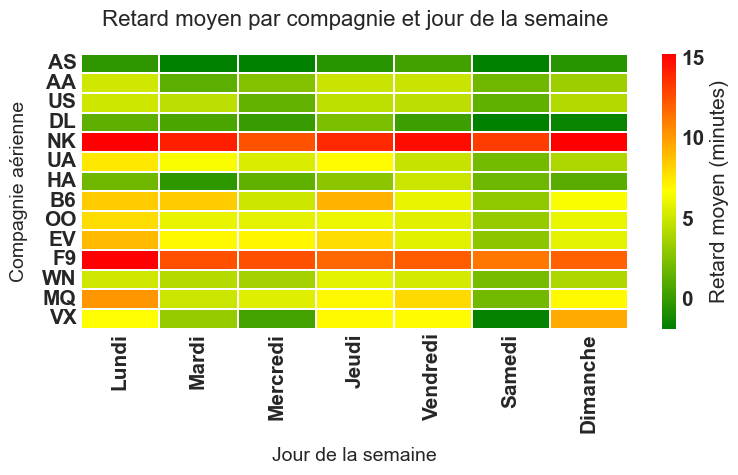

In [189]:
# Retards par Compagnie et Jour de la Semaine
Days = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
Airline_Day_Stats = pd.DataFrame()

for a in df['AIRLINE'].unique():
    x = df[df['AIRLINE'] == a]
    t = x['ARRIVAL_DELAY'].groupby(x['DAY']).mean()
    Airline_Day_Stats[a] = t

Airline_Day_Stats.dropna(inplace=True)

# Visualisation
plt.figure(figsize=(8, 5))
sns.heatmap(
    Airline_Day_Stats.T, 
    linewidths=0.01, 
    cmap=LinearSegmentedColormap.from_list('rg', ["green", "yellow", "red"], N=256),
    robust=True, 
    yticklabels=True,
    xticklabels=Days,
    cbar_kws={'label': 'Retard moyen (minutes)'}
)

plt.xlabel("Jour de la semaine", fontsize=14, labelpad=10)
plt.ylabel("Compagnie aérienne", fontsize=14, labelpad=10)
plt.title("Retard moyen par compagnie et jour de la semaine", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 2.3.2 Matrice de corrélation

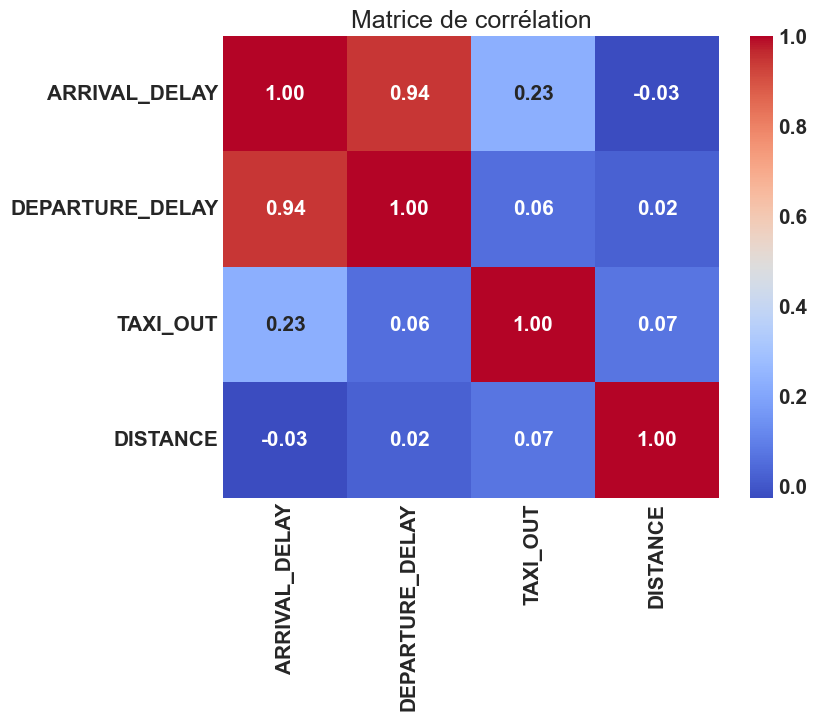

In [192]:
corr_vars = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'TAXI_OUT', 'DISTANCE']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation")
plt.show()

## 2.4 Analyse TEMPORELLE

### 2.4.1 Retard selon l'heure de départ

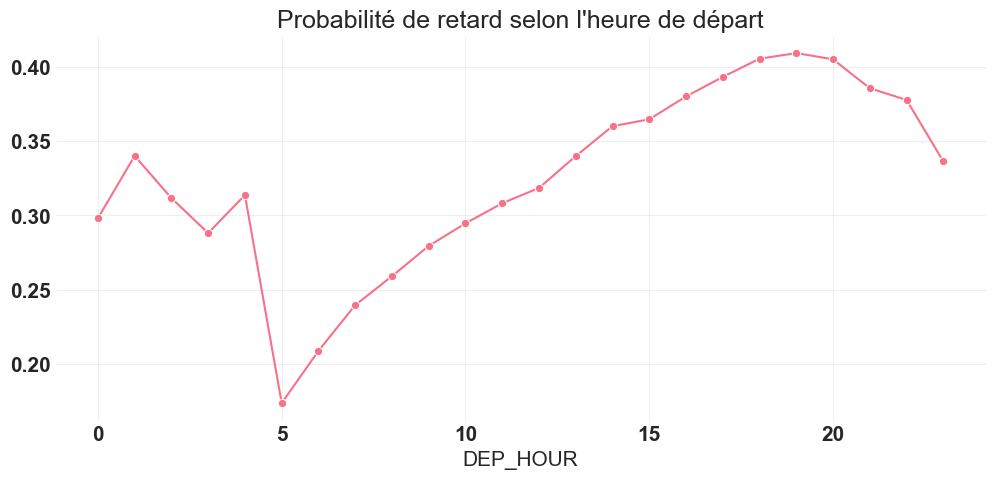

In [196]:
df['DEP_HOUR'] = df['SCHEDULED_DEPARTURE'].apply(lambda x: x.hour)
hour_delay = df.groupby('DEP_HOUR')['DELAY_BINARY'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hour_delay.index, y=hour_delay.values, marker='o')
plt.title("Probabilité de retard selon l'heure de départ")
plt.grid(alpha=0.3)
plt.show()

### 2.4.2 Évolution mensuelle des retards

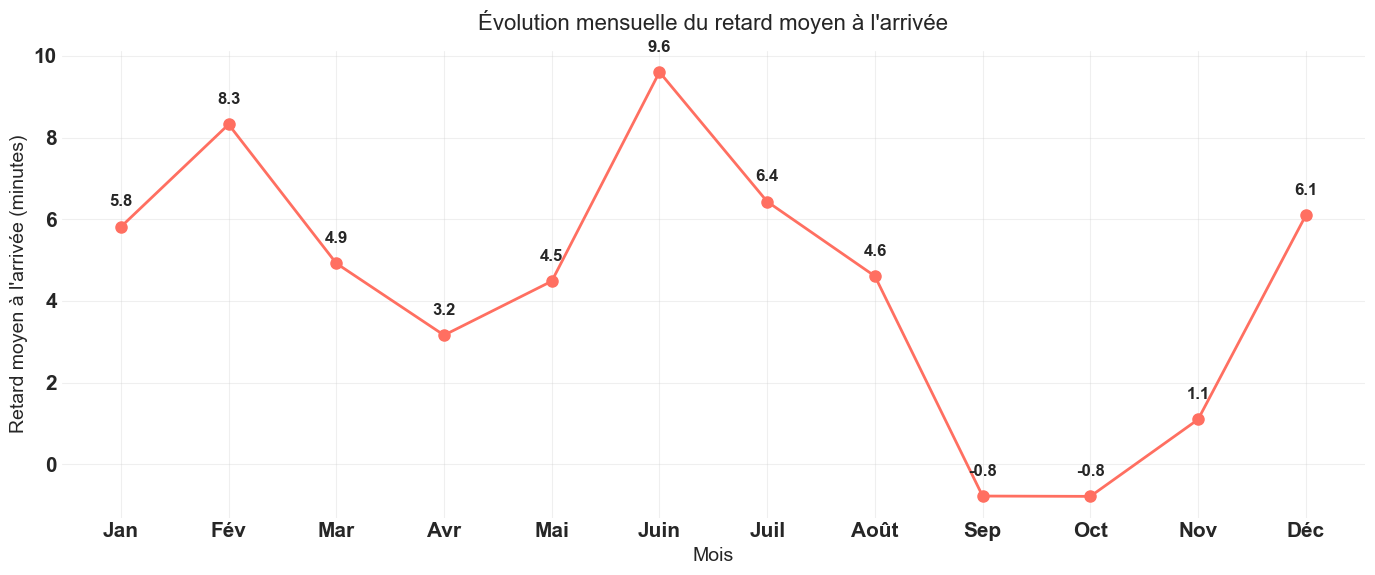

In [199]:
monthly_delay = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_delay.index, monthly_delay.values, marker='o', linestyle='-', 
         linewidth=2, markersize=8, color='#FF6F61')

# Ajouter des annotations sur chaque point
for month, delay in zip(monthly_delay.index, monthly_delay.values):
    plt.text(month, delay + 0.5, f'{delay:.1f}', ha='center', fontsize=12, fontweight='bold')

plt.xticks(range(1, 13), ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", 
                          "Juil", "Août", "Sep", "Oct", "Nov", "Déc"])
plt.xlabel("Mois", fontsize=14)
plt.ylabel("Retard moyen à l'arrivée (minutes)", fontsize=14)
plt.title("Évolution mensuelle du retard moyen à l'arrivée", fontsize=16, pad=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5 Analyse GÉOGRAPHIQUE

### 2.5.1 Carte des aéroports et volume de trafic

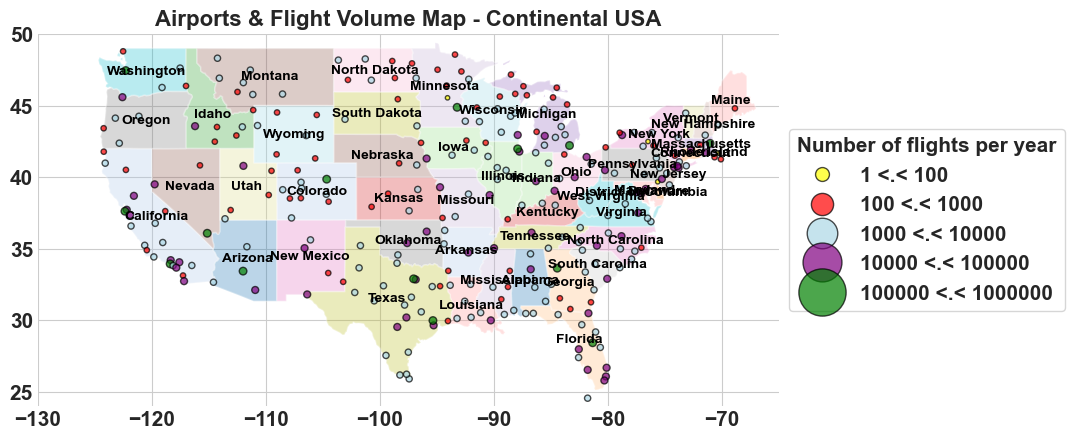

In [203]:

# -----------------------------
# GeoDataFrame des aéroports
# -----------------------------
airports['geometry'] = airports.apply(lambda row: Point(row['LONGITUDE'], row['LATITUDE']), axis=1)
gdf_airports = gpd.GeoDataFrame(airports, geometry='geometry').set_crs(epsg=4326)

# Nombre de vols par aéroport
count_flights = df['ORIGIN'].value_counts()
gdf_airports['flight_count'] = gdf_airports['IATA_CODE'].map(count_flights).fillna(0)

# -----------------------------
# Seuils pour taille des cercles et couleurs par volume
# -----------------------------
size_limits = [1, 100, 1000, 10000, 100000, 1000000]
volume_colors = ['yellow', 'red', 'lightblue', 'purple', 'green']  # 5 intervalles
labels = ["{} <.< {}".format(size_limits[i], size_limits[i+1]) for i in range(len(size_limits)-1)]

def get_marker_props(flight_count):
    isize = [i for i, val in enumerate(size_limits) if val < flight_count]
    ind = 0 if len(isize) == 0 else min(isize[-1], len(volume_colors)-1)
    size = ind*5 + 10  # ajustable
    color = volume_colors[ind]
    return size, color

gdf_airports[['size','color']] = gdf_airports['flight_count'].apply(lambda x: pd.Series(get_marker_props(x)))

# -----------------------------
# Fond de carte USA
# -----------------------------
world = gpd.read_file("https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson")
world = world.to_crs(epsg=4326)
usa_map = world[world['ISO3166-1-Alpha-3'] == 'USA']

# États USA
states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
states = states.to_crs(epsg=4326)

# -----------------------------
# Générer une couleur unique pour chaque État
# -----------------------------
n_states = len(states)
state_colors = cm.get_cmap('tab20', n_states)
states['fill_color'] = [state_colors(i) for i in range(n_states)]

# -----------------------------
# Zoom continental USA
# -----------------------------
gdf_usa = gdf_airports[(gdf_airports['LONGITUDE'] >= -130) & (gdf_airports['LONGITUDE'] <= -65) &
                       (gdf_airports['LATITUDE'] >= 24) & (gdf_airports['LATITUDE'] <= 50)]
states_cont = states.cx[-130:-65, 24:50]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11,11))

# États avec couleurs distinctes (un seul plot)
states_cont.plot(ax=ax, color=states_cont['fill_color'], edgecolor='white', linewidth=1.2, alpha=0.3)

# Tracer les aéroports au-dessus
ax.scatter(gdf_usa['LONGITUDE'], gdf_usa['LATITUDE'],
           s=gdf_usa['size'], c=gdf_usa['color'], alpha=0.7, edgecolor='k', zorder=5)

# Ajouter noms des États
for idx, row in states_cont.iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['name'], fontsize=10, fontweight='bold',
            color='black', ha='center', va='center', zorder=6)

# -----------------------------
# Légende avec seuils (décalée)
# -----------------------------
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=volume_colors[i],
                  markersize=(i*6 + 10), label=labels[i], alpha=0.7, markeredgecolor='k')
           for i in range(len(labels))]
plt.legend(handles=handles, title='Number of flights per year', 
           loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)

# Limites du zoom continental USA
ax.set_xlim(-130, -65)
ax.set_ylim(24, 50)

ax.set_title("Airports & Flight Volume Map - Continental USA", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [205]:

# Calcul des statistiques descriptives des retards au départ
# pour chaque compagnie aérienne
global_stats = (
    df.groupby('AIRLINE_NAME')['ARRIVAL_DELAY']
      .agg(['min', 'max', 'count', 'mean'])
      .sort_values('count')
)

global_stats


,min,max,count,mean
AIRLINE_NAME,,,,
Virgin America,-81.000,651.000,61248,4.738
Hawaiian Airlines Inc.,-67.000,1467.000,76041,2.023
Frontier Airlines Inc.,-73.000,1101.000,90090,12.505
Spirit Air Lines,-60.000,833.000,115193,14.472
Alaska Airlines Inc.,-82.000,950.000,171439,-0.977
US Airways Inc.,-87.000,750.000,194223,3.706
JetBlue Airways,-76.000,1002.000,262042,6.678
American Eagle Airlines Inc.,-63.000,1528.000,278791,6.458
United Air Lines Inc.,-81.000,1294.000,507762,5.432


###### L’analyse des retards à l’arrivée (ARRIVAL_DELAY, en minutes) révèle une forte hétérogénéité inter-compagnies. Les arrivées anticipées sont fréquentes (min −87 minutes pour US et AA, −60 pour NK), tandis que des retards extrêmes apparaissent ponctuellement (max 1 971 min pour AA, 1 528 pour MQ, 1 467 pour HA). En moyenne, les retards restent modérés, avec AS (−0,98 min) et HA (2,02 min) proches de l’horaire prévu, alors que NK (14,47 min), F9 (12,50 min) et B6 (6,68 min) présentent des retards plus élevés. Le volume d’observations varie de 61 248 (VX) à plus de 1,24 million (WN), assurant une robustesse statistique des estimations, tout en soulignant l’influence potentielle des outliers sur les moyennes.

# Machine learning models 

### Apprentissage supervisé

In [210]:
# --- 1. Filtrer pour le mois de novembre
Data = df[df['MONTH'] == 6].copy()

# Sélection des features importantes
Data = Data[['ARRIVAL_DELAY', 'ORIGIN', 'DESTINATION', 'DISTANCE', 'TAXI_OUT', 
             'DEPARTURE_DELAY', 'DATE', 'DAY', 'AIRLINE', 
             'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL','DELAY_BINARY']].copy()

# Supprimer colonnes originales de temps
Data.drop(['SCHEDULED_DEPARTURE','SCHEDULED_ARRIVAL','DATE'], axis=1, inplace=True)

# Séparer features et target
X = Data.drop(['ARRIVAL_DELAY','DELAY_BINARY'], axis=1)
Y = Data['DELAY_BINARY']

print("Distribution des classes (0=Pas de retard, 1=Retard):")
print(Y.value_counts(normalize=True))

Distribution des classes (0=Pas de retard, 1=Retard):
DELAY_BINARY
0   0.619
1   0.381
Name: proportion, dtype: float64


In [212]:
# --- 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

# --- 3. One-Hot Encoding des variables catégorielles
categorical_cols = ['AIRLINE','ORIGIN','DESTINATION']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# Concaténer avec les features numériques
X_train_final = np.concatenate([X_train[numerical_cols].to_numpy(), X_train_cat], axis=1)
X_test_final = np.concatenate([X_test[numerical_cols].to_numpy(), X_test_cat], axis=1)


In [214]:
# --- 4. Standardisation
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

print(f"Après encodage + standardisation: X_train_final: {X_train_final.shape}, X_test_final: {X_test_final.shape}")
print(f"y_train: {np.bincount(y_train)}, y_test: {np.bincount(y_test)}")

Après encodage + standardisation: X_train_final: (344992, 643), X_test_final: (147855, 643)
y_train: [213565 131427], y_test: [91528 56327]


In [216]:
# --- Initialisation du DataFrame des métriques
metrics_df = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1"
])



=== Logistic Regression ===
=== Métriques d'évaluation ===

--- Ensemble d'entraînement ---
Accuracy: 0.8842
Balanced Accuracy: 0.8649
Precision: 0.8994
Recall: 0.7837
F1-Score: 0.8376
ROC AUC: 0.8649

--- Ensemble de test ---
Accuracy: 0.8845
Balanced Accuracy: 0.8651
Precision: 0.8999
Recall: 0.7839
F1-Score: 0.8379
ROC AUC: 0.8651


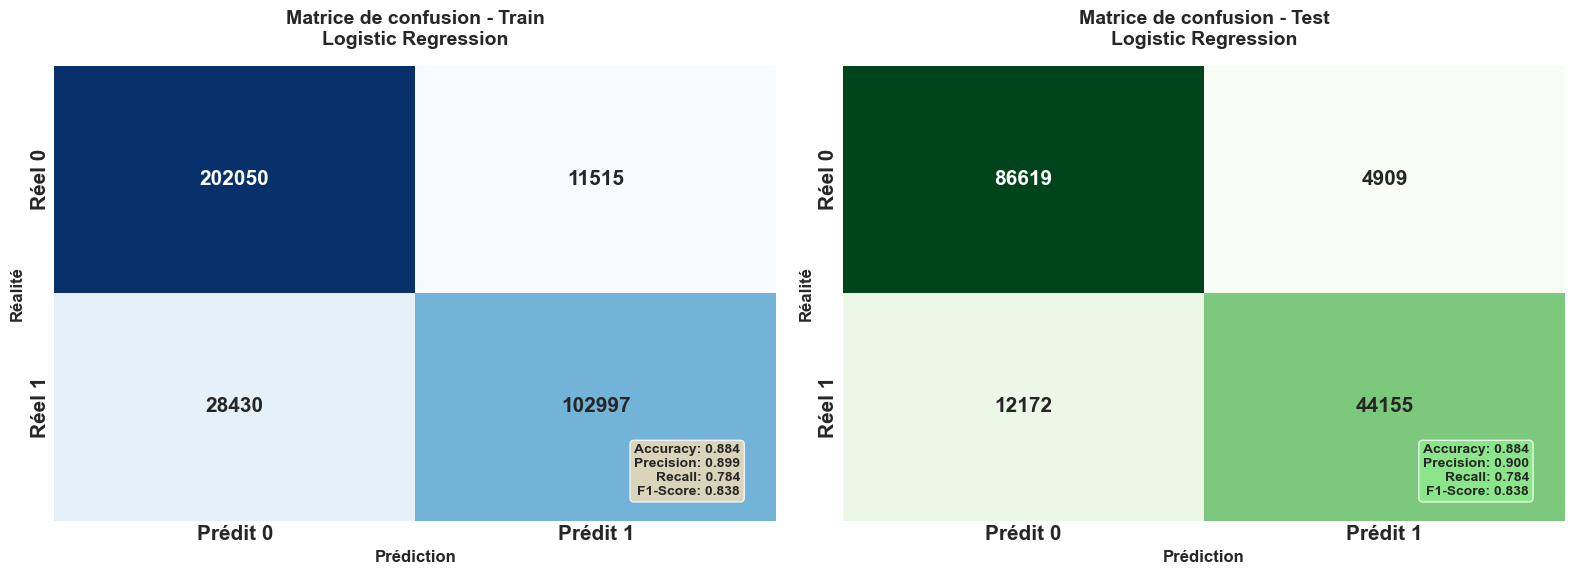


=== DataFrame des métriques ===
                         Model  Accuracy  Balanced_Accuracy  Precision  \
6  Logistic Regression (Train)     0.884              0.865      0.899   
7   Logistic Regression (Test)     0.884              0.865      0.900   

   Recall    F1  
6   0.784 0.838  
7   0.784 0.838  


In [228]:


# ==========================
# Modèle 1 : Régression Logistique
# ==========================

model_name = "Logistic Regression"

logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(X_train_final, y_train)

# Prédictions sur train et test
y_pred_train = logistic_model.predict(X_train_final)
y_pred_test = logistic_model.predict(X_test_final)

# Calcul des métriques pour train et test
def calculate_metrics(y_true, y_pred, dataset_name):
    return {
        'Dataset': dataset_name,
        'Accuracy': metrics.accuracy_score(y_true, y_pred),
        'Balanced Accuracy': metrics.balanced_accuracy_score(y_true, y_pred),
        'Precision': metrics.precision_score(y_true, y_pred),
        'Recall': metrics.recall_score(y_true, y_pred),
        'F1-Score': metrics.f1_score(y_true, y_pred),
        'ROC AUC': metrics.roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else None
    }

metrics_train = calculate_metrics(y_train, y_pred_train, "Train")
metrics_test = calculate_metrics(y_test, y_pred_test, "Test")

# Stockage dans le DataFrame global
metrics_df.loc[len(metrics_df)] = [
    model_name + " (Train)", 
    metrics_train['Accuracy'], 
    metrics_train['Balanced Accuracy'], 
    metrics_train['Precision'], 
    metrics_train['Recall'], 
    metrics_train['F1-Score']
]

metrics_df.loc[len(metrics_df)] = [
    model_name + " (Test)", 
    metrics_test['Accuracy'], 
    metrics_test['Balanced Accuracy'], 
    metrics_test['Precision'], 
    metrics_test['Recall'], 
    metrics_test['F1-Score']
]

# Affichage des métriques
print(f"\n=== {model_name} ===")
print("=== Métriques d'évaluation ===")
print("\n--- Ensemble d'entraînement ---")
for key, value in metrics_train.items():
    if key != 'Dataset' and value is not None:
        print(f"{key}: {value:.4f}")

print("\n--- Ensemble de test ---")
for key, value in metrics_test.items():
    if key != 'Dataset' and value is not None:
        print(f"{key}: {value:.4f}")

# Création de la figure avec deux sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de confusion - Train
cm_train = metrics.confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[0].set_xlabel('Prédiction', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Réalité', fontsize=12, fontweight='bold')
axes[0].set_title(f"Matrice de confusion - Train\n{model_name}", fontsize=14, fontweight='bold', pad=15)

# Ajout des métriques sur le graphique train
train_text = (f"Accuracy: {metrics_train['Accuracy']:.3f}\n"
              f"Precision: {metrics_train['Precision']:.3f}\n"
              f"Recall: {metrics_train['Recall']:.3f}\n"
              f"F1-Score: {metrics_train['F1-Score']:.3f}")
axes[0].text(0.95, 0.05, train_text, transform=axes[0].transAxes,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=10)

# Matrice de confusion - Test
cm_test = metrics.confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[1].set_xlabel('Prédiction', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Réalité', fontsize=12, fontweight='bold')
axes[1].set_title(f"Matrice de confusion - Test\n{model_name}", fontsize=14, fontweight='bold', pad=15)

# Ajout des métriques sur le graphique test
test_text = (f"Accuracy: {metrics_test['Accuracy']:.3f}\n"
             f"Precision: {metrics_test['Precision']:.3f}\n"
             f"Recall: {metrics_test['Recall']:.3f}\n"
             f"F1-Score: {metrics_test['F1-Score']:.3f}")
axes[1].text(0.95, 0.05, test_text, transform=axes[1].transAxes,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
             fontsize=10)

# Ajustement de l'espacement
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig(f"confusion_matrix_{model_name.lower().replace(' ', '_')}_train_test.png", 
            dpi=300, bbox_inches='tight')
plt.show()

# Affichage du DataFrame des métriques
print(f"\n=== DataFrame des métriques ===")
print(metrics_df.tail(2))  # Affiche les 2 dernières lignes (train et test)


=== Random Forest ===
=== Métriques d'évaluation ===

--- Ensemble d'entraînement ---
Accuracy: 0.9969
Balanced Accuracy: 0.9963
Precision: 0.9984
Recall: 0.9935
F1-Score: 0.9960
ROC AUC: 0.9963

--- Ensemble de test ---
Accuracy: 0.8756
Balanced Accuracy: 0.8581
Precision: 0.8761
Recall: 0.7845
F1-Score: 0.8278
ROC AUC: 0.8581


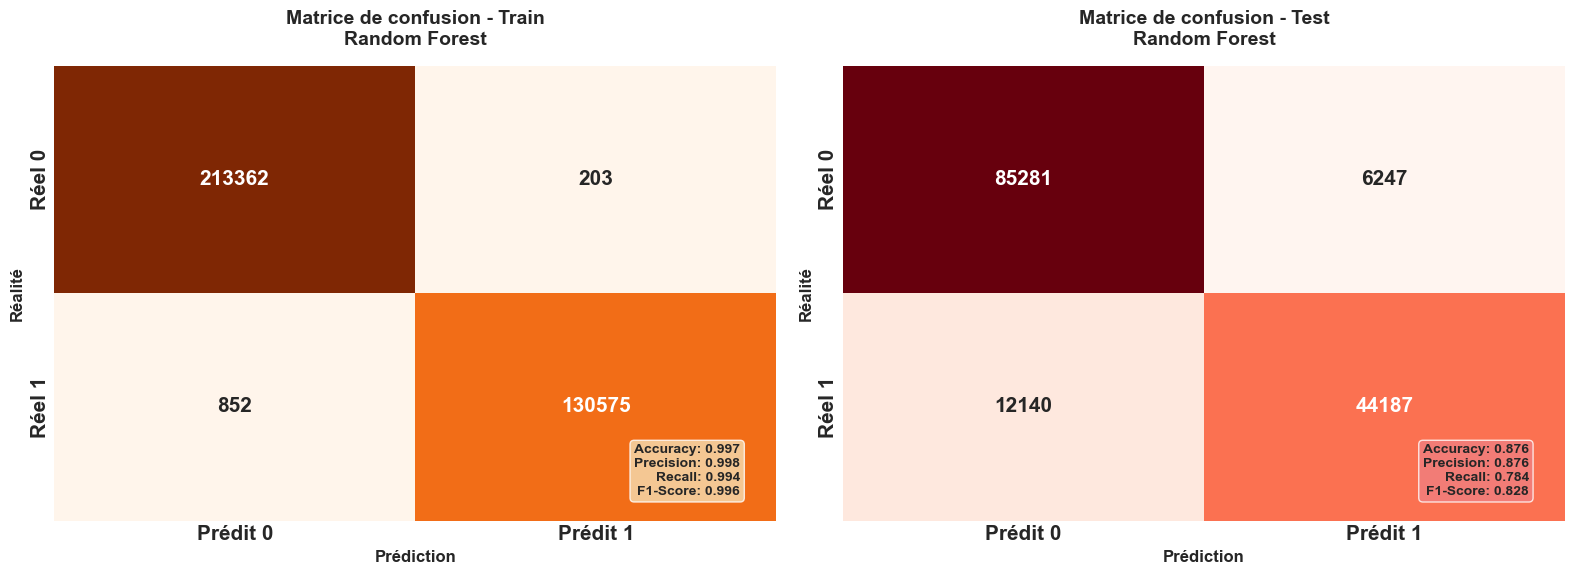


=== DataFrame des métriques ===
                    Model  Accuracy  Balanced_Accuracy  Precision  Recall  \
14  Random Forest (Train)     0.997              0.996      0.998   0.994   
15   Random Forest (Test)     0.876              0.858      0.876   0.784   

      F1  
14 0.996  
15 0.828  


In [237]:
# ==========================
# Modèle 2 : Random Forest
# ==========================

model_name = "Random Forest"

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)
rf_model.fit(X_train_final, y_train)

# Prédictions sur train et test
y_pred_train = rf_model.predict(X_train_final)
y_pred_test = rf_model.predict(X_test_final)

# Calcul des métriques pour train et test
def calculate_metrics(y_true, y_pred, dataset_name):
    return {
        'Dataset': dataset_name,
        'Accuracy': metrics.accuracy_score(y_true, y_pred),
        'Balanced Accuracy': metrics.balanced_accuracy_score(y_true, y_pred),
        'Precision': metrics.precision_score(y_true, y_pred),
        'Recall': metrics.recall_score(y_true, y_pred),
        'F1-Score': metrics.f1_score(y_true, y_pred),
        'ROC AUC': metrics.roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else None
    }

metrics_train = calculate_metrics(y_train, y_pred_train, "Train")
metrics_test = calculate_metrics(y_test, y_pred_test, "Test")

# Stockage dans le DataFrame global
metrics_df.loc[len(metrics_df)] = [
    model_name + " (Train)", 
    metrics_train['Accuracy'], 
    metrics_train['Balanced Accuracy'], 
    metrics_train['Precision'], 
    metrics_train['Recall'], 
    metrics_train['F1-Score']
]

metrics_df.loc[len(metrics_df)] = [
    model_name + " (Test)", 
    metrics_test['Accuracy'], 
    metrics_test['Balanced Accuracy'], 
    metrics_test['Precision'], 
    metrics_test['Recall'], 
    metrics_test['F1-Score']
]

# Affichage des métriques
print(f"\n=== {model_name} ===")
print("=== Métriques d'évaluation ===")
print("\n--- Ensemble d'entraînement ---")
for key, value in metrics_train.items():
    if key != 'Dataset' and value is not None:
        print(f"{key}: {value:.4f}")

print("\n--- Ensemble de test ---")
for key, value in metrics_test.items():
    if key != 'Dataset' and value is not None:
        print(f"{key}: {value:.4f}")

# Création de la figure avec deux sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de confusion - Train
cm_train = metrics.confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[0],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[0].set_xlabel('Prédiction', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Réalité', fontsize=12, fontweight='bold')
axes[0].set_title(f"Matrice de confusion - Train\n{model_name}", fontsize=14, fontweight='bold', pad=15)

# Ajout des métriques sur le graphique train
train_text = (f"Accuracy: {metrics_train['Accuracy']:.3f}\n"
              f"Precision: {metrics_train['Precision']:.3f}\n"
              f"Recall: {metrics_train['Recall']:.3f}\n"
              f"F1-Score: {metrics_train['F1-Score']:.3f}")
axes[0].text(0.95, 0.05, train_text, transform=axes[0].transAxes,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=10)

# Matrice de confusion - Test
cm_test = metrics.confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Reds", cbar=False, ax=axes[1],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[1].set_xlabel('Prédiction', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Réalité', fontsize=12, fontweight='bold')
axes[1].set_title(f"Matrice de confusion - Test\n{model_name}", fontsize=14, fontweight='bold', pad=15)

# Ajout des métriques sur le graphique test
test_text = (f"Accuracy: {metrics_test['Accuracy']:.3f}\n"
             f"Precision: {metrics_test['Precision']:.3f}\n"
             f"Recall: {metrics_test['Recall']:.3f}\n"
             f"F1-Score: {metrics_test['F1-Score']:.3f}")
axes[1].text(0.95, 0.05, test_text, transform=axes[1].transAxes,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8),
             fontsize=10)

# Ajustement de l'espacement
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig(f"confusion_matrix_{model_name.lower().replace(' ', '_')}_train_test.png", 
            dpi=300, bbox_inches='tight')
plt.show()

# Affichage du DataFrame des métriques
print(f"\n=== DataFrame des métriques ===")
print(metrics_df.tail(2))  # Affiche les 2 dernières lignes (train et test)


=== Gradient Boosting ===
=== Métriques d'évaluation ===

--- Ensemble d'entraînement ---
Accuracy: 0.8781
Balanced Accuracy: 0.8563
Precision: 0.9003
Recall: 0.7648
F1-Score: 0.8270
ROC AUC: 0.8563

--- Ensemble de test ---
Accuracy: 0.8791
Balanced Accuracy: 0.8573
Precision: 0.9019
Recall: 0.7659
F1-Score: 0.8284
ROC AUC: 0.8573


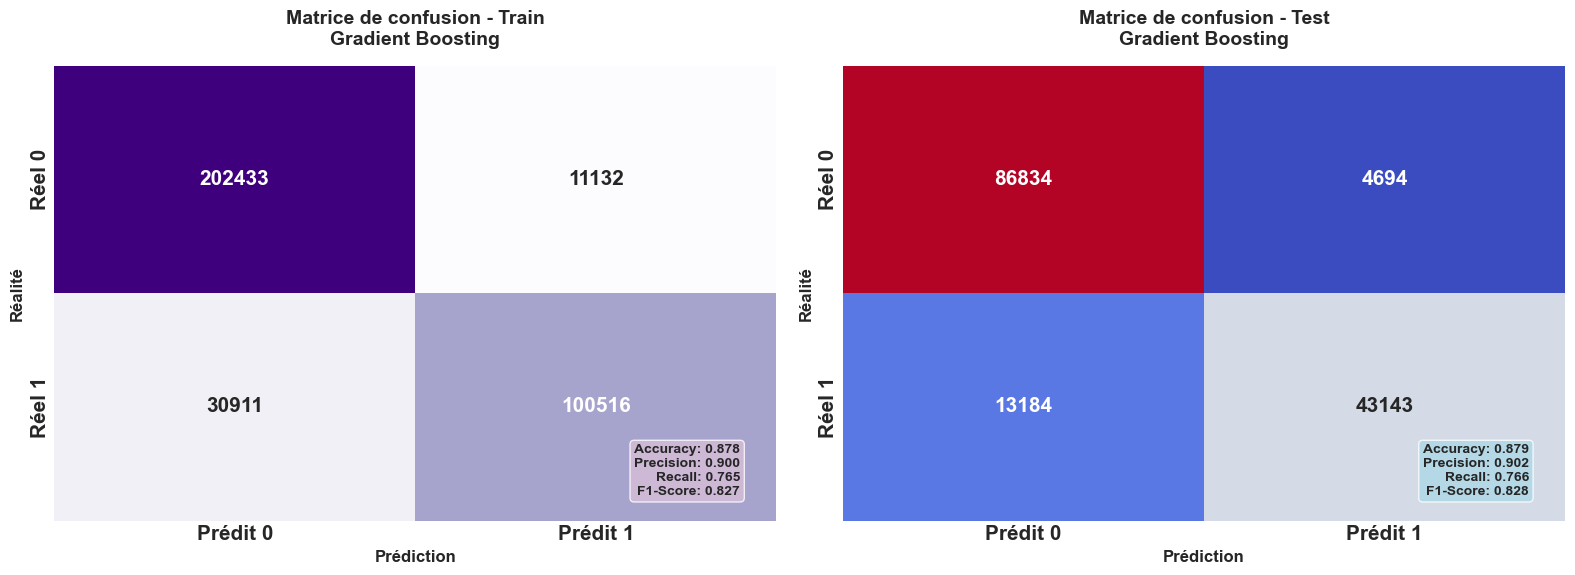


=== DataFrame des métriques ===
                        Model  Accuracy  Balanced_Accuracy  Precision  Recall  \
16  Gradient Boosting (Train)     0.878              0.856      0.900   0.765   
17   Gradient Boosting (Test)     0.879              0.857      0.902   0.766   

      F1  
16 0.827  
17 0.828  


In [239]:
# ==========================
# Modèle 3 : Gradient Boosting
# ==========================
from sklearn.ensemble import GradientBoostingClassifier

model_name = "Gradient Boosting"

gb_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100
)
gb_model.fit(X_train_final, y_train)

# Prédictions sur train et test
y_pred_train = gb_model.predict(X_train_final)
y_pred_test = gb_model.predict(X_test_final)

# Calcul des métriques pour train et test
metrics_train = calculate_metrics(y_train, y_pred_train, "Train")
metrics_test = calculate_metrics(y_test, y_pred_test, "Test")

# Stockage dans le DataFrame global
metrics_df.loc[len(metrics_df)] = [
    model_name + " (Train)", 
    metrics_train['Accuracy'], 
    metrics_train['Balanced Accuracy'], 
    metrics_train['Precision'], 
    metrics_train['Recall'], 
    metrics_train['F1-Score']
]

metrics_df.loc[len(metrics_df)] = [
    model_name + " (Test)", 
    metrics_test['Accuracy'], 
    metrics_test['Balanced Accuracy'], 
    metrics_test['Precision'], 
    metrics_test['Recall'], 
    metrics_test['F1-Score']
]

# Affichage des métriques
print(f"\n=== {model_name} ===")
print("=== Métriques d'évaluation ===")
print("\n--- Ensemble d'entraînement ---")
for key, value in metrics_train.items():
    if key != 'Dataset' and value is not None:
        print(f"{key}: {value:.4f}")

print("\n--- Ensemble de test ---")
for key, value in metrics_test.items():
    if key != 'Dataset' and value is not None:
        print(f"{key}: {value:.4f}")

# Création de la figure avec deux sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de confusion - Train
cm_train = metrics.confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[0],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[0].set_xlabel('Prédiction', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Réalité', fontsize=12, fontweight='bold')
axes[0].set_title(f"Matrice de confusion - Train\n{model_name}", fontsize=14, fontweight='bold', pad=15)

# Ajout des métriques sur le graphique train
train_text = (f"Accuracy: {metrics_train['Accuracy']:.3f}\n"
              f"Precision: {metrics_train['Precision']:.3f}\n"
              f"Recall: {metrics_train['Recall']:.3f}\n"
              f"F1-Score: {metrics_train['F1-Score']:.3f}")
axes[0].text(0.95, 0.05, train_text, transform=axes[0].transAxes,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='thistle', alpha=0.8),
             fontsize=10)

# Matrice de confusion - Test
cm_test = metrics.confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="coolwarm", cbar=False, ax=axes[1],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[1].set_xlabel('Prédiction', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Réalité', fontsize=12, fontweight='bold')
axes[1].set_title(f"Matrice de confusion - Test\n{model_name}", fontsize=14, fontweight='bold', pad=15)

# Ajout des métriques sur le graphique test
test_text = (f"Accuracy: {metrics_test['Accuracy']:.3f}\n"
             f"Precision: {metrics_test['Precision']:.3f}\n"
             f"Recall: {metrics_test['Recall']:.3f}\n"
             f"F1-Score: {metrics_test['F1-Score']:.3f}")
axes[1].text(0.95, 0.05, test_text, transform=axes[1].transAxes,
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
             fontsize=10)

# Ajustement de l'espacement
plt.tight_layout()

# Sauvegarde et affichage
plt.savefig(f"confusion_matrix_{model_name.lower().replace(' ', '_')}_train_test.png", 
            dpi=300, bbox_inches='tight')
plt.show()

# Affichage du DataFrame des métriques
print(f"\n=== DataFrame des métriques ===")
print(metrics_df.tail(2))  # Affiche les 2 dernières lignes (train et test)

In [253]:
 # ==========================
# Comparaison globale des modèles
# ==========================

metrics_df.sort_values("Balanced_Accuracy", ascending=False)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1
8,Random Forest (Train),0.997,0.996,0.998,0.994,0.996
14,Random Forest (Train),0.997,0.996,0.998,0.994,0.996
0,Logistic Regression,0.884,0.865,0.900,0.784,0.838
3,Logistic Regression (Test),0.884,0.865,0.900,0.784,0.838
5,Logistic Regression (Test),0.884,0.865,0.900,0.784,0.838
7,Logistic Regression (Test),0.884,0.865,0.900,0.784,0.838
1,Logistic Regression,0.884,0.865,0.900,0.784,0.838
2,Logistic Regression (Train),0.884,0.865,0.899,0.784,0.838
4,Logistic Regression (Train),0.884,0.865,0.899,0.784,0.838
6,Logistic Regression (Train),0.884,0.865,0.899,0.784,0.838


In [292]:
# ==========================
# DataFrame final de comparaison des modèles (TEST uniquement)
# ==========================
# 1. Filtrer uniquement les résultats de test
df_test = metrics_df[metrics_df["Model"].str.contains("(Test)", na=False)].copy()

# 2. Extraire le nom de base du modèle
df_test["Model_Base"] = df_test["Model"].str.replace(" (Test)", "", regex=False)

# 3. Garder seulement les modèles
models_list = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
df_test = df_test[df_test["Model_Base"].isin(models_list)]

# 4. Supprimer les doublons (garder la dernière occurrence)
df_test_unique = df_test.drop_duplicates(subset=['Model_Base'], keep='last')

# 5. Trier par Balanced Accuracy
df_final = df_test_unique.sort_values("Balanced_Accuracy", ascending=False)

# 6. Sélectionner et réorganiser les colonnes
df_final = df_final[['Model_Base', 'Accuracy', 'Balanced_Accuracy', 
                     'Precision', 'Recall', 'F1']]

# 7. Renommer les colonnes pour un affichage plus propre
df_final.columns = ['Modèle', 'Accuracy', 'Balanced Accuracy', 
                    'Precision', 'Recall', 'F1-Score']

# 8. Réinitialiser l'index
df_final = df_final.reset_index(drop=True)

# 9. Formater les valeurs avec 4 décimales
for col in ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_final[col] = df_final[col].apply(lambda x: f"{x:.4f}")

# 10. Afficher le tableau final
print("\n" + df_final.to_string(index=False))

print("\n" + "=" * 80)

# 11. Afficher aussi les données brutes pour vérification
print("\nDonnées brutes (format numérique) :")
df_final_numeric = df_test_unique.sort_values("Balanced_Accuracy", ascending=False)
df_final_numeric = df_final_numeric[['Model_Base', 'Accuracy', 'Balanced_Accuracy', 
                                     'Precision', 'Recall', 'F1']]
df_final_numeric.columns = ['Modèle', 'Accuracy', 'Balanced Accuracy', 
                           'Precision', 'Recall', 'F1-Score']
print(df_final_numeric.to_string(index=False))

print("\n" + "=" * 80)

# 12. Export en CSV
df_final_numeric.to_csv("comparaison_finale_modeles.csv", index=False)
print("Tableau exporté dans: comparaison_finale_modeles.csv")

# ==========================
# EXPORT EN FORMAT LaTeX
# ==========================

# Version avec 4 décimales pour LaTeX
df_final_latex = df_final_numeric.copy()

# Arrondir à 4 décimales
for col in ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_final_latex[col] = df_final_latex[col].round(4)

# CORRECTION : Utiliser escape=True et des noms sans accents
# Créer une copie avec noms de colonnes sans accents pour LaTeX
df_final_latex_safe = df_final_latex.copy()
df_final_latex_safe.columns = ['Modele', 'Accuracy', 'Balanced Accuracy', 
                              'Precision', 'Recall', 'F1-Score']

# Option 1 : Utiliser escape=True (recommandé)
latex_code = df_final_latex_safe.to_latex(
    index=False,
    caption="Comparaison des performances des modèles sur l'ensemble de test",
    label="tab:modele_comparaison",
    column_format='l|ccccc',
    float_format="%.4f",
    escape=True  # ← CORRECTION ICI : escape=True pour éviter les problèmes d'accents
)

# Améliorer le format LaTeX (optionnel)
latex_code = latex_code.replace('\\toprule', '\\hline')
latex_code = latex_code.replace('\\midrule', '\\hline')
latex_code = latex_code.replace('\\bottomrule', '\\hline')

# Remplacer "Modele" par "Modèle" dans le code généré
latex_code = latex_code.replace('Modele', 'Modèle')

print("\n" + "=" * 80)
print("CODE LaTeX GÉNÉRÉ")
print("=" * 80)
print(latex_code)

# Sauvegarder dans un fichier .tex
with open("comparaison_modeles_latex.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)

print("Code LaTeX exporté dans: comparaison_modeles_latex.tex")


             Modèle Accuracy Balanced Accuracy Precision Recall F1-Score
Logistic Regression   0.8845            0.8651    0.8999 0.7839   0.8379
      Random Forest   0.8756            0.8581    0.8761 0.7845   0.8278
  Gradient Boosting   0.8791            0.8573    0.9019 0.7659   0.8284


Données brutes (format numérique) :
             Modèle  Accuracy  Balanced Accuracy  Precision  Recall  F1-Score
Logistic Regression     0.884              0.865      0.900   0.784     0.838
      Random Forest     0.876              0.858      0.876   0.784     0.828
  Gradient Boosting     0.879              0.857      0.902   0.766     0.828

Tableau exporté dans: comparaison_finale_modeles.csv

CODE LaTeX GÉNÉRÉ
\begin{table}
\caption{Comparaison des performances des modèles sur l'ensemble de test}
\label{tab:modele_comparaison}
\begin{tabular}{l|ccccc}
\hline
Modèle & Accuracy & Balanced Accuracy & Precision & Recall & F1-Score \\
\hline
Logistic Regression & 0.8845 & 0.8651 & 0.8999 & 0.78

In [ ]:
# visualisation courbe roc auc

In [257]:
y_prob_log = logistic_model.predict_proba(X_test_final)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test_final)[:, 1]
y_prob_gb  = gb_model.predict_proba(X_test_final)[:, 1]


In [261]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_gb,  tpr_gb,  _ = roc_curve(y_test, y_prob_gb)


auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_gb  = auc(fpr_gb, tpr_gb)



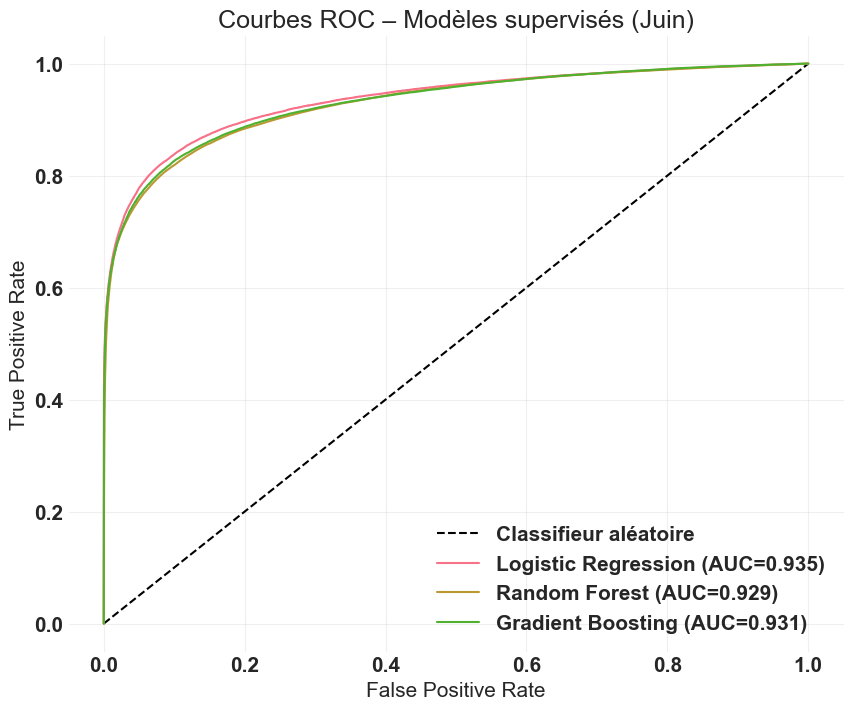

In [284]:
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Classifieur aléatoire')

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.3f})')
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_gb,  tpr_gb,  label=f'Gradient Boosting (AUC={auc_gb:.3f})')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC – Modèles supervisés (Juin)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png')
plt.show()


### Apprentissage non supervisé

In [276]:
# %% [markdown]
# ## Extraction automatique des variables quantitatives et qualitatives

# %%
# Colonnes numériques et qualitatives à partir de X_train
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

num = X_train[numerical_cols].copy()
quali = X_train[categorical_cols].copy()

print("Variables numériques :", numerical_cols)
print("Variables qualitatives :", categorical_cols)


Variables numériques : ['DISTANCE', 'TAXI_OUT', 'DEPARTURE_DELAY', 'DAY']
Variables qualitatives : ['ORIGIN', 'DESTINATION', 'AIRLINE']


In [278]:
# %% [markdown]
# ## Sous-échantillon pour clustering

# %%
sample_size = min(5000, len(X_train))
np.random.seed(42)
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train.iloc[sample_indices][numerical_cols].copy()  # uniquement num

print(f"Taille du sous-échantillon pour clustering: {X_sample.shape}")


Taille du sous-échantillon pour clustering: (5000, 4)


In [280]:
# %% [markdown]
# ## Standardisation

# %%
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)


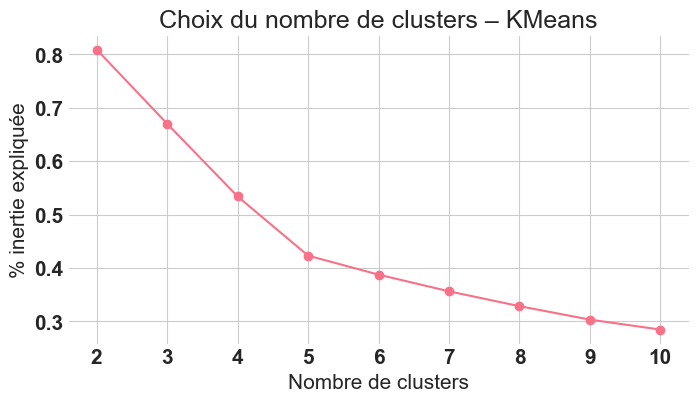

In [282]:
# %% [markdown]
# ## K-Means

# %%
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Déterminer inertie expliquée pour k = 2 à 10
inertia_expl = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample_scaled)
    between = km.inertia_  # inertia interne (sum of squared distances to cluster centers)
    total = np.sum((X_sample_scaled - X_sample_scaled.mean(axis=0))**2)
    inertia_expl.append(between / total)

# Plot de l'inertie expliquée
plt.figure(figsize=(8,4))
plt.plot(K_range, inertia_expl, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("% inertie expliquée")
plt.title("Choix du nombre de clusters – KMeans")
plt.show()


In [205]:
# %% [markdown]
# ## Application K-Means avec k optimal

# %%
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_sample_scaled)

# Ajout des labels au DataFrame
X_sample_kmeans = X_sample.copy()
X_sample_kmeans['Cluster_KMeans'] = kmeans_labels

# Distribution des clusters
print(X_sample_kmeans['Cluster_KMeans'].value_counts())


Cluster_KMeans
1    2020
2    1774
4     750
0     268
3     188
Name: count, dtype: int64


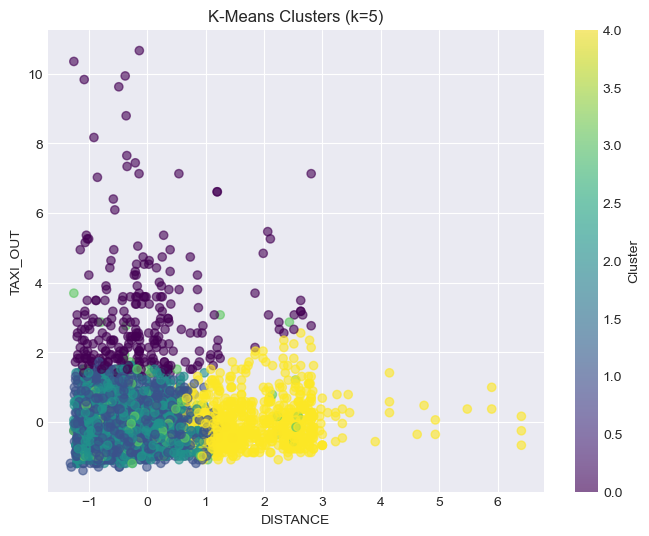

In [207]:
# %% [markdown]
# ## Visualisation des clusters (scatter plot 2D)

# %%
plt.figure(figsize=(8,6))
plt.scatter(
    X_sample_scaled[:,0], X_sample_scaled[:,1],
    c=kmeans_labels, cmap='viridis', alpha=0.6
)
plt.xlabel(numerical_cols[0])
plt.ylabel(numerical_cols[1])
plt.title(f"K-Means Clusters (k={optimal_k})")
plt.colorbar(label='Cluster')
plt.show()


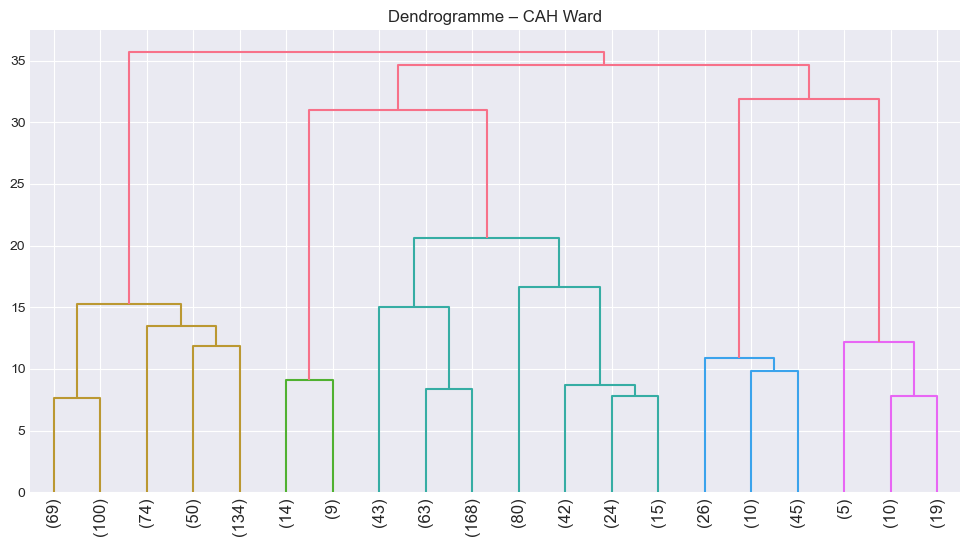

In [209]:
# %% [markdown]
# ## Classification Ascendante Hiérarchique (Ward)

# %%
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# CAH sur 1000 premiers échantillons pour lisibilité
data_cah = X_sample_scaled[:1000]
dist_mat = pdist(data_cah)
cah_ward = linkage(dist_mat, method='ward')

plt.figure(figsize=(12,6))
dendrogram(cah_ward, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title("Dendrogramme – CAH Ward")
plt.show()
